# Figures

## PIN Pricing


In [58]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


def find_project_root(start: Path | None = None) -> Path:
    s = (start or Path.cwd()).resolve()
    for c in [s, *s.parents]:
        if (c / "outputs").exists() and (c / "scripts").exists():
            return c
    raise RuntimeError("No se pudo localizar la raiz del proyecto.")


def load_points(project_root: Path, run_name: str) -> pd.DataFrame:
    csv_path = project_root / f"outputs/pinn/{run_name}/cos_benchmark/points_pinn_vs_cos.csv"
    if not csv_path.exists():
        raise FileNotFoundError(csv_path)
    df = pd.read_csv(csv_path)
    if "abs_error" not in df.columns:
        df["abs_error"] = np.abs(df["error"].to_numpy(dtype=np.float64))
    if "rel_abs_error" not in df.columns:
        denom = np.maximum(np.abs(df["price_cos"].to_numpy(dtype=np.float64)), 1e-4)
        df["rel_abs_error"] = df["abs_error"].to_numpy(dtype=np.float64) / denom
    return df


def apply_plot_style(*, font_family="DejaVu Sans", font_size=14, axes_labelsize=18,
                     tick_labelsize=16, legend_fontsize=14, axes_titlesize=16,
                     figure_dpi=120, savefig_dpi=400, grid_alpha=0.25):
    plt.rcParams.update({
        "font.family": font_family,
        "font.size": font_size,
        "axes.labelsize": axes_labelsize,
        "xtick.labelsize": tick_labelsize,
        "ytick.labelsize": tick_labelsize,
        "legend.fontsize": legend_fontsize,
        "axes.titlesize": axes_titlesize,
        "figure.dpi": figure_dpi,
        "savefig.dpi": savefig_dpi,
        "axes.grid": True,
        "grid.alpha": grid_alpha,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })


def plot_scatter_parity(df: pd.DataFrame, *, title="", color="#1f77b4", alpha=0.35,
                        marker_size=14, diag_color="black", diag_style="--",
                        points_label="PINN prices", diag_label="y = x",
                        figsize=(10, 10), show_legend=True):
    lo = float(np.nanmin([df["price_cos"].min(), df["price_pinn"].min()]))
    hi = float(np.nanmax([df["price_cos"].max(), df["price_pinn"].max()]))
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(
        df["price_cos"],
        df["price_pinn"],
        s=marker_size,
        alpha=alpha,
        edgecolors="none",
        color=color,
        label=points_label,
    )
    ax.plot([lo, hi], [lo, hi], diag_style, color=diag_color, lw=1.2, label=diag_label)
    ax.set_xlabel("COS price")
    ax.set_ylabel("PINN price")
    if title:
        ax.set_title(title)
    if show_legend:
        ax.legend(loc="best")
    plt.show()
    return fig


def plot_abs_error_cdf(df: pd.DataFrame, *, title="", color="#ff7f0e", line_width=1.8,
                       figsize=(12, 7), show_legend=False):
    vals = np.sort(df["abs_error"].to_numpy(dtype=np.float64))
    cdf = np.linspace(0, 1, len(vals), endpoint=False)
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(vals, cdf, lw=line_width, color=color, label="CDF")
    ax.set_xscale("log")
    ax.set_xlabel("|PINN - COS|")
    ax.set_ylabel("CDF")
    ax.grid(True, which="major", axis="both", alpha=0.30)
    ax.grid(True, which="minor", axis="x", alpha=0.22)
    if title:
        ax.set_title(title)
    if show_legend:
        ax.legend(loc="lower right")
    plt.show()
    return fig


def _binned_matrix(df: pd.DataFrame, value_col: str, n_bins: int):
    tau = df["tau"].to_numpy(dtype=np.float64)
    m = df["moneyness"].to_numpy(dtype=np.float64)
    v = df[value_col].to_numpy(dtype=np.float64)
    tau_edges = np.linspace(np.min(tau), np.max(tau), n_bins + 1)
    m_edges = np.linspace(np.min(m), np.max(m), n_bins + 1)
    tau_idx = np.clip(np.digitize(tau, tau_edges) - 1, 0, n_bins - 1)
    m_idx = np.clip(np.digitize(m, m_edges) - 1, 0, n_bins - 1)
    sums = np.zeros((n_bins, n_bins), dtype=np.float64)
    counts = np.zeros((n_bins, n_bins), dtype=np.int64)
    np.add.at(sums, (tau_idx, m_idx), v)
    np.add.at(counts, (tau_idx, m_idx), 1)
    mean = np.divide(sums, np.maximum(counts, 1), out=np.full_like(sums, np.nan), where=counts > 0)
    return mean, counts, tau_edges, m_edges


def plot_heatmap(df: pd.DataFrame, *, value_col: str, cbar_label: str = "", title="", n_bins=24,
                 cmap="magma", log_scale=True, figsize=(14, 8.8)):
    if value_col == "count":
        _, counts, tau_edges, m_edges = _binned_matrix(df, "abs_error", n_bins)
        matrix = counts.astype(float)
        log_scale = False
    else:
        matrix, _, tau_edges, m_edges = _binned_matrix(df, value_col, n_bins)

    fig, ax = plt.subplots(figsize=figsize)
    plot_matrix = matrix
    norm = None
    if log_scale:
        valid = np.isfinite(matrix) & (matrix > 0)
        if np.any(valid):
            vals = matrix[valid]
            vmin = max(float(np.nanpercentile(vals, 5)), float(np.finfo(np.float64).tiny))
            vmax = float(np.nanpercentile(vals, 95))
            if vmax <= vmin:
                vmax = vmin * 10.0
            norm = LogNorm(vmin=vmin, vmax=vmax)
            plot_matrix = np.where(np.isfinite(matrix), np.maximum(matrix, vmin), np.nan)

    im = ax.imshow(
        plot_matrix.T,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        extent=[tau_edges[0], tau_edges[-1], m_edges[0], m_edges[-1]],
        cmap=cmap,
        norm=norm,
    )
    cbar = plt.colorbar(im, ax=ax)
    if cbar_label:
        cbar.set_label(cbar_label)
    ax.set_xlabel("τ", fontsize=20)
    ax.set_ylabel("m", fontsize=20)
    ax.tick_params(axis="both", labelsize=16)
    if title:
        ax.set_title(title)
    plt.show()
    return fig


def save_figures(figs: dict[str, plt.Figure], out_dir: Path, dpi=400):
    out_dir.mkdir(parents=True, exist_ok=True)
    for name, fig in figs.items():
        fig.savefig(out_dir / name, dpi=dpi, bbox_inches="tight")
        print(out_dir / name)



def plot_loss_curve_from_history(history_df: pd.DataFrame, *, title: str = "", figsize=(12, 7),
                                 color="#1f77b4", line_width=1.8):
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(history_df["epoch"], history_df["loss_total"], color=color, lw=line_width)
    ax.set_yscale("log")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.grid(True, which="major", axis="both", alpha=0.30)
    ax.grid(True, which="minor", axis="y", alpha=0.22)
    if title:
        ax.set_title(title)
    plt.show()
    return fig


def _mean_grid_from_arrays(tau: np.ndarray, m: np.ndarray, values: np.ndarray, n_bins: int):
    tau_edges = np.linspace(np.min(tau), np.max(tau), n_bins + 1)
    m_edges = np.linspace(np.min(m), np.max(m), n_bins + 1)
    tau_idx = np.clip(np.digitize(tau, tau_edges) - 1, 0, n_bins - 1)
    m_idx = np.clip(np.digitize(m, m_edges) - 1, 0, n_bins - 1)

    sums = np.zeros((n_bins, n_bins), dtype=np.float64)
    counts = np.zeros((n_bins, n_bins), dtype=np.int64)
    np.add.at(sums, (tau_idx, m_idx), values)
    np.add.at(counts, (tau_idx, m_idx), 1)
    mean = np.divide(sums, np.maximum(counts, 1), out=np.full_like(sums, np.nan), where=counts > 0)
    return mean, tau_edges, m_edges


def plot_greek_error_panel(df: pd.DataFrame, *, metric_prefix: str,
                           greek_order=("delta", "gamma", "vega", "theta", "rho"),
                           n_bins: int = 24, cmap: str = "magma", log_scale: bool = True,
                           cbar_label: str = "", figsize=(18, 11), with_titles: bool = False):
    tau = df["tau"].to_numpy(dtype=np.float64)
    m = df["moneyness"].to_numpy(dtype=np.float64)

    # 3 arriba y 2 centradas abajo
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(2, 6)
    axes = [
        fig.add_subplot(gs[0, 0:2]),
        fig.add_subplot(gs[0, 2:4]),
        fig.add_subplot(gs[0, 4:6]),
        fig.add_subplot(gs[1, 1:3]),
        fig.add_subplot(gs[1, 3:5]),
    ]

    im_last = None
    for i, greek in enumerate(greek_order):
        if i >= len(axes):
            break
        ax = axes[i]
        col = f"{metric_prefix}_{greek}"
        if col not in df.columns:
            ax.axis("off")
            continue

        values = df[col].to_numpy(dtype=np.float64)
        matrix, tau_edges, m_edges = _mean_grid_from_arrays(tau, m, values, n_bins=n_bins)

        plot_matrix = matrix
        norm = None
        if log_scale:
            valid = np.isfinite(matrix) & (matrix > 0)
            if np.any(valid):
                vals = matrix[valid]
                vmin = max(float(np.nanpercentile(vals, 5)), float(np.finfo(np.float64).tiny))
                vmax = float(np.nanpercentile(vals, 95))
                if vmax <= vmin:
                    vmax = vmin * 10.0
                norm = LogNorm(vmin=vmin, vmax=vmax)
                plot_matrix = np.where(np.isfinite(matrix), np.maximum(matrix, vmin), np.nan)

        im = ax.imshow(
            plot_matrix.T,
            origin="lower",
            aspect="auto",
            interpolation="nearest",
            extent=[tau_edges[0], tau_edges[-1], m_edges[0], m_edges[-1]],
            cmap=cmap,
            norm=norm,
        )
        im_last = im
        ax.set_xlabel("τ", fontsize=20)
        ax.set_ylabel("m", fontsize=20)
        ax.tick_params(axis="both", labelsize=16)

        if with_titles:
            ax.set_title(f"{metric_prefix} - {greek}")

    if im_last is not None:
        cbar = fig.colorbar(im_last, ax=axes, shrink=0.92, pad=0.01)
        cbar.ax.tick_params(labelsize=14)
        if cbar_label:
            cbar.set_label(cbar_label)

    plt.show()
    return fig



def plot_greek_hist_panel(df: pd.DataFrame, *,
                          greek_order=("delta", "gamma", "vega", "theta", "rho"),
                          bins: int = 140, color: str = "#1f77b4", alpha: float = 0.75,
                          figsize=(18, 11), with_titles: bool = False):
    # 3 arriba y 2 centradas abajo
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(2, 6)
    axes = [
        fig.add_subplot(gs[0, 0:2]),
        fig.add_subplot(gs[0, 2:4]),
        fig.add_subplot(gs[0, 4:6]),
        fig.add_subplot(gs[1, 1:3]),
        fig.add_subplot(gs[1, 3:5]),
    ]

    for i, greek in enumerate(greek_order):
        if i >= len(axes):
            break
        ax = axes[i]
        col = f"error_{greek}"
        if col not in df.columns:
            ax.axis("off")
            continue

        values = df[col].to_numpy(dtype=np.float64)
        values = values[np.isfinite(values)]
        if values.size == 0:
            ax.axis("off")
            continue

        # Recorte robusto para no deformar por outliers extremos.
        lo, hi = np.nanpercentile(values, [0.2, 99.8])
        if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
            values_plot = values[(values >= lo) & (values <= hi)]
        else:
            values_plot = values

        ax.hist(values_plot, bins=bins, density=True, color=color, alpha=alpha, edgecolor="none")
        ax.set_xlabel("error", fontsize=20)
        ax.set_ylabel("densidad", fontsize=20)
        ax.tick_params(axis="both", labelsize=16)
        ax.grid(True, which="major", axis="both", alpha=0.30)

        if with_titles:
            ax.set_title(greek)

    plt.show()
    return fig


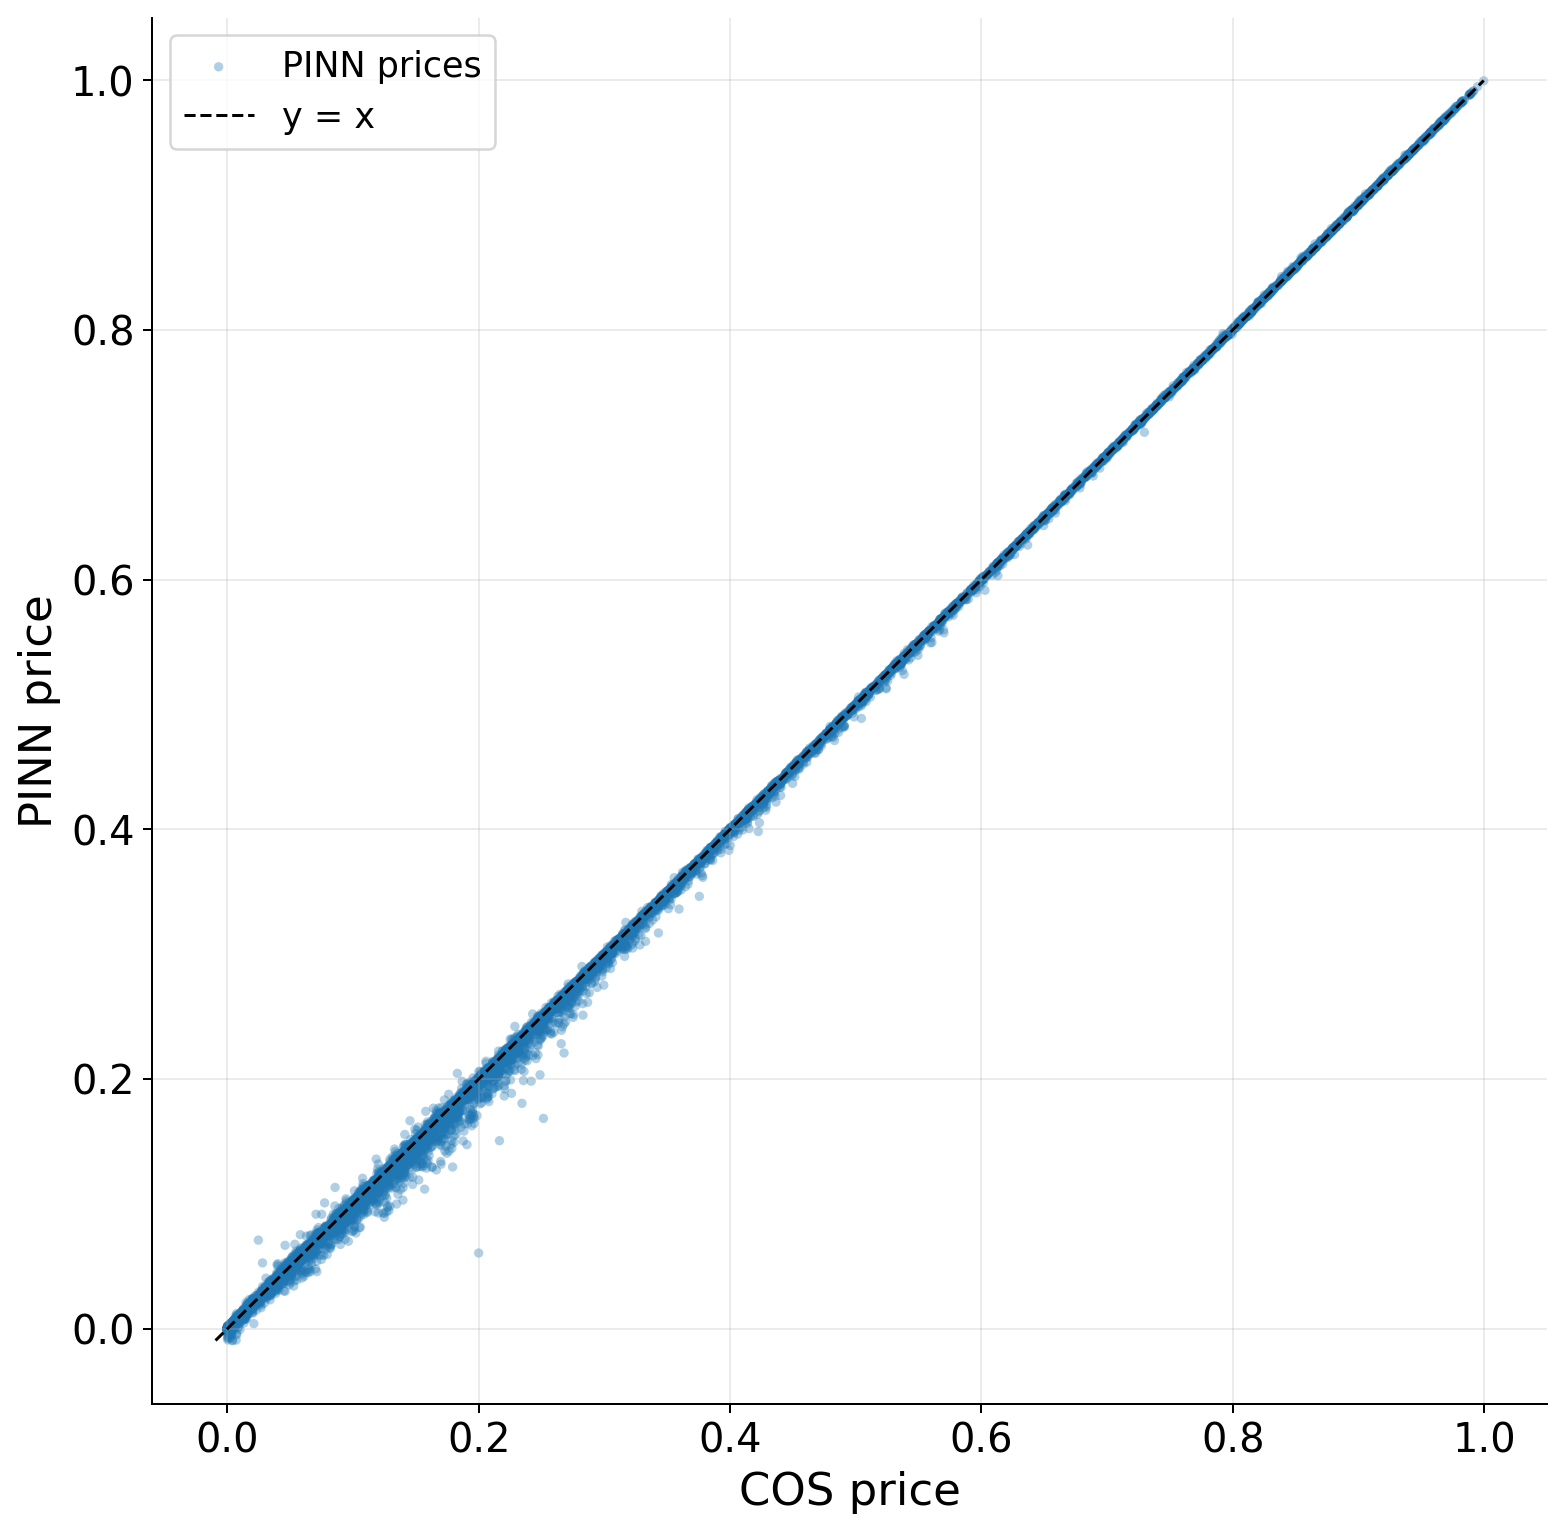

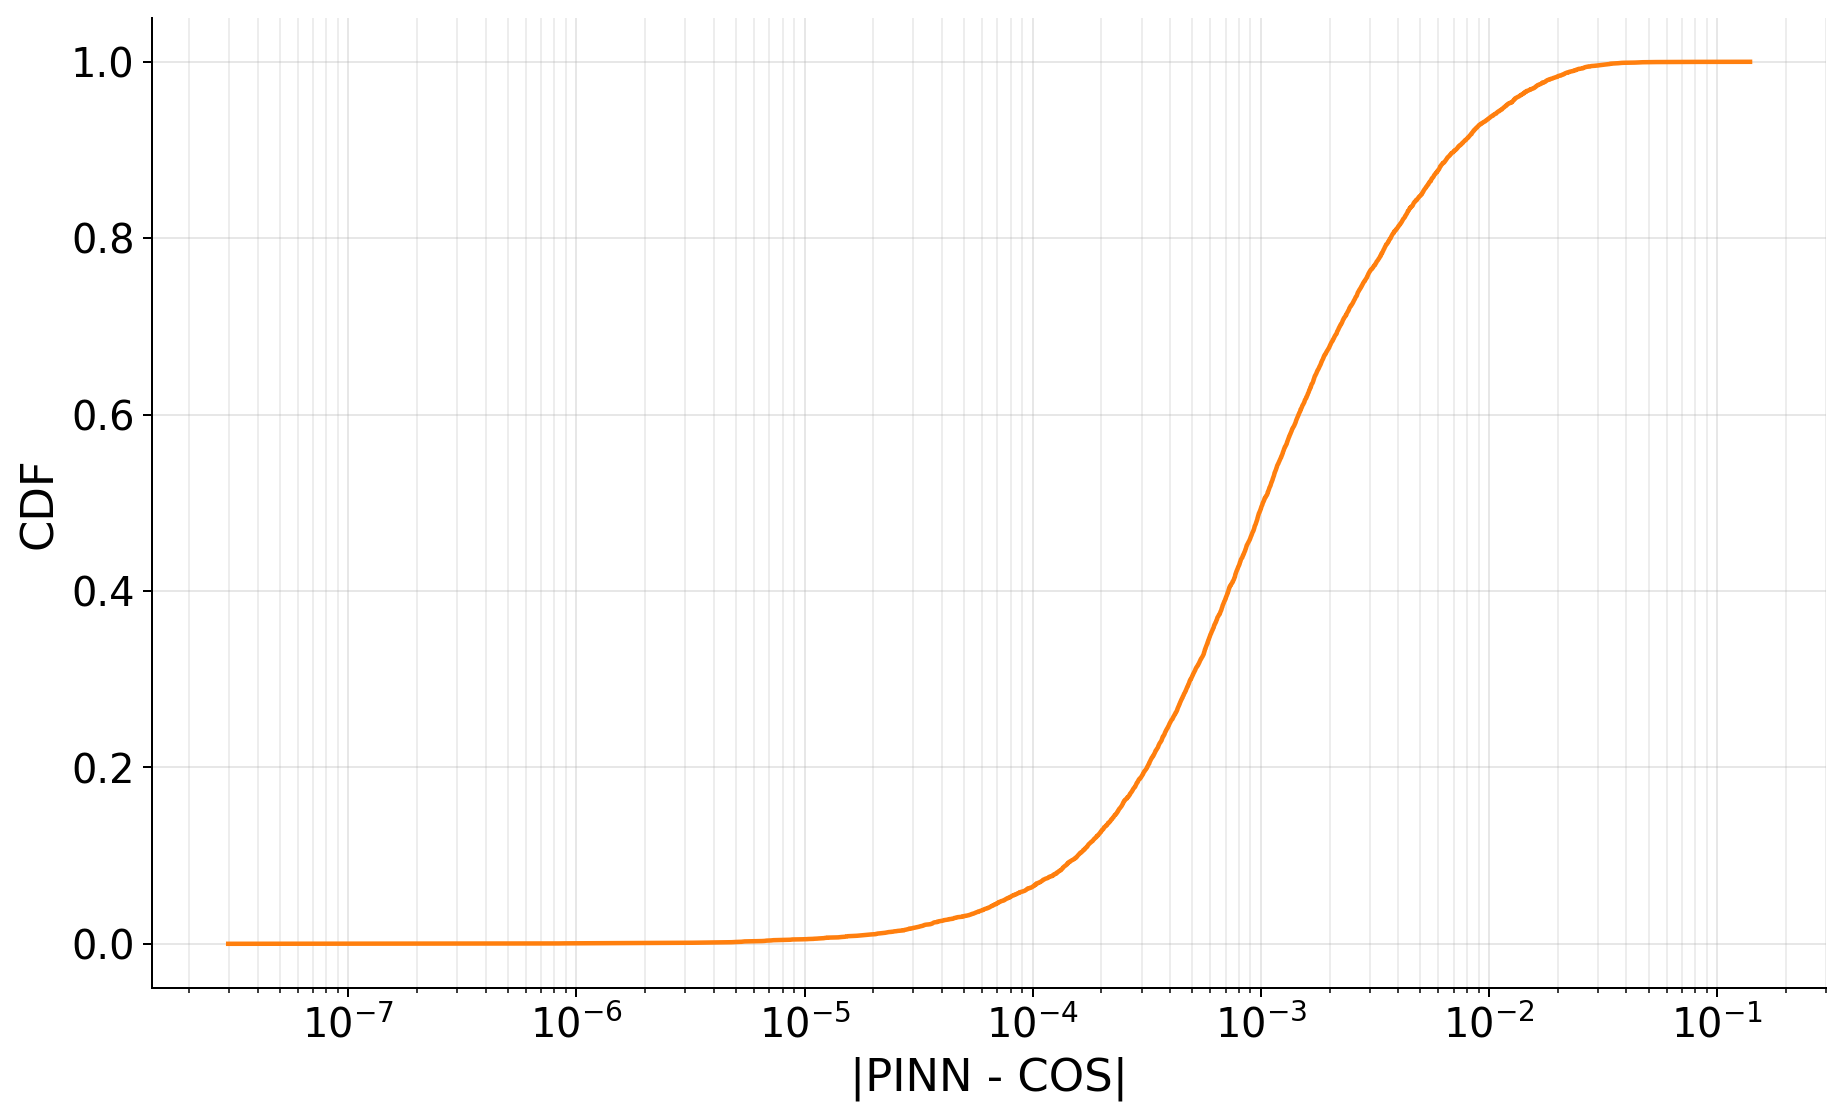

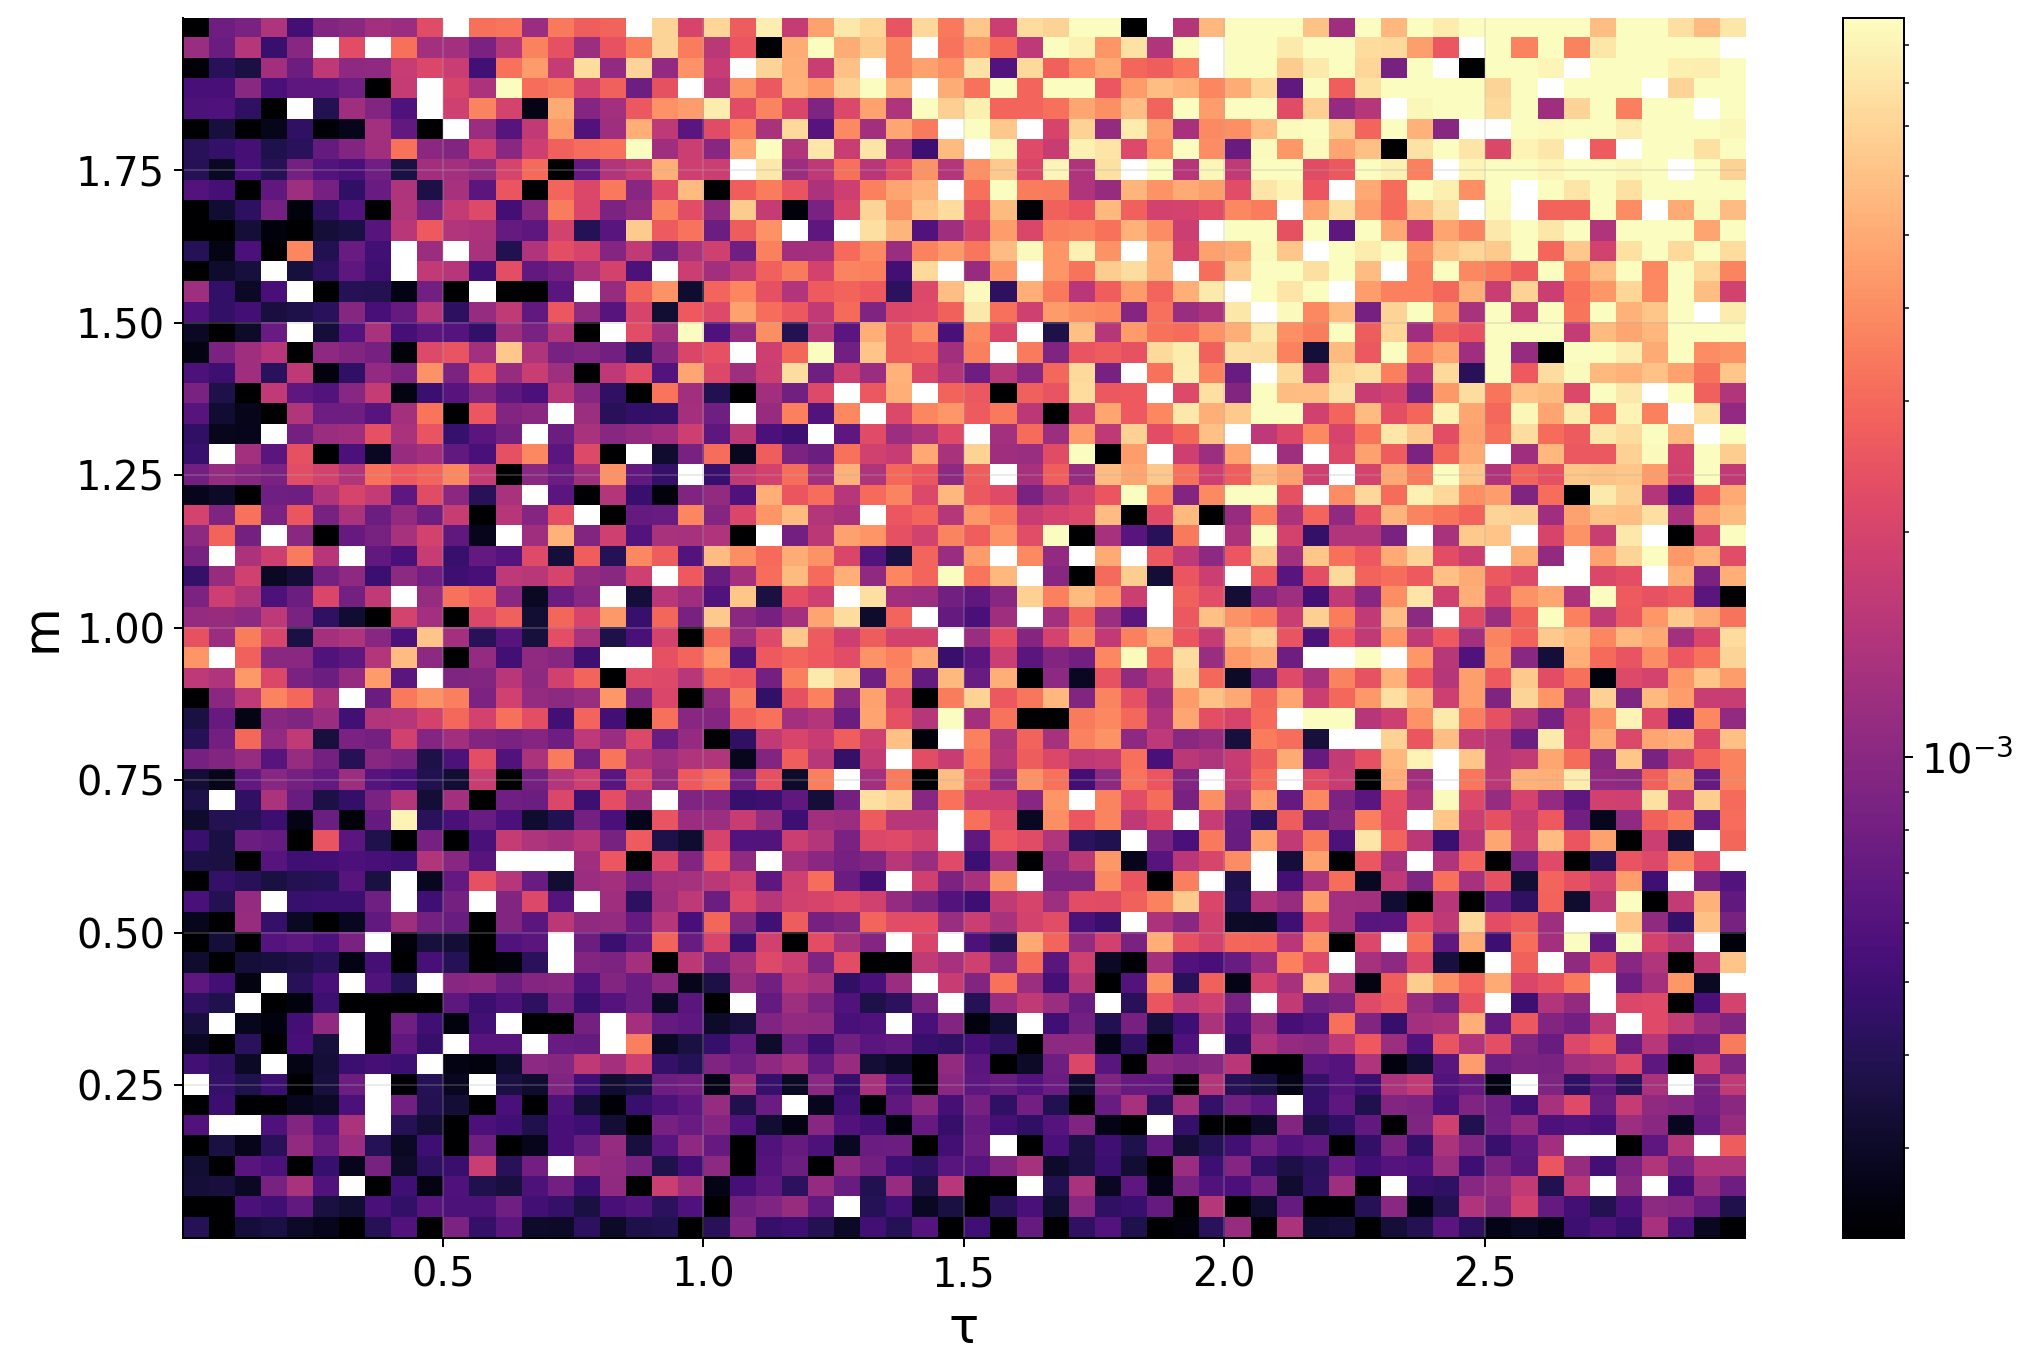

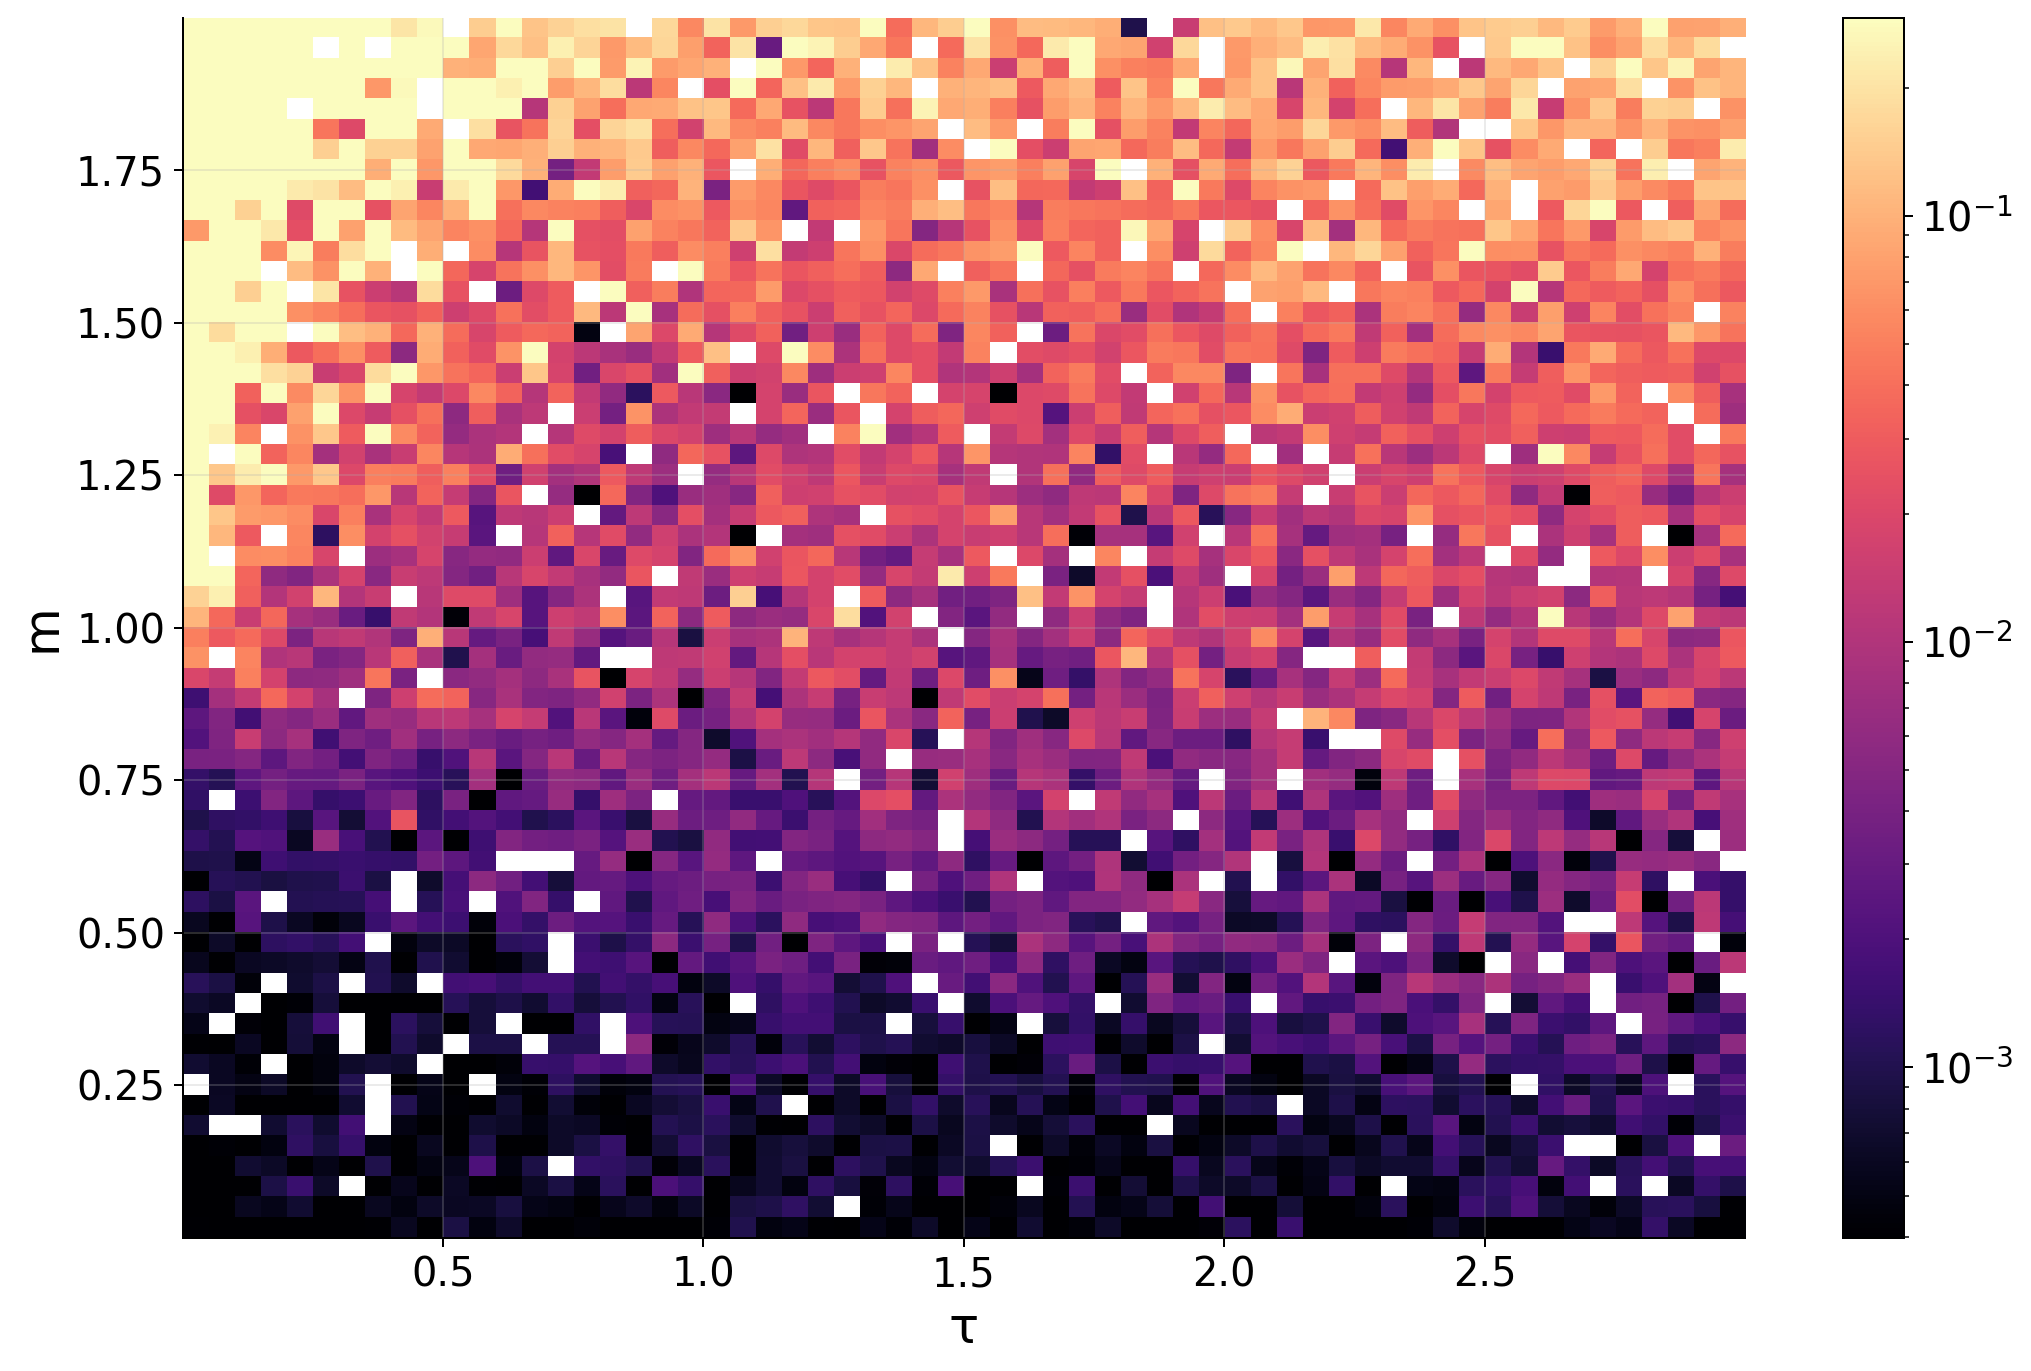

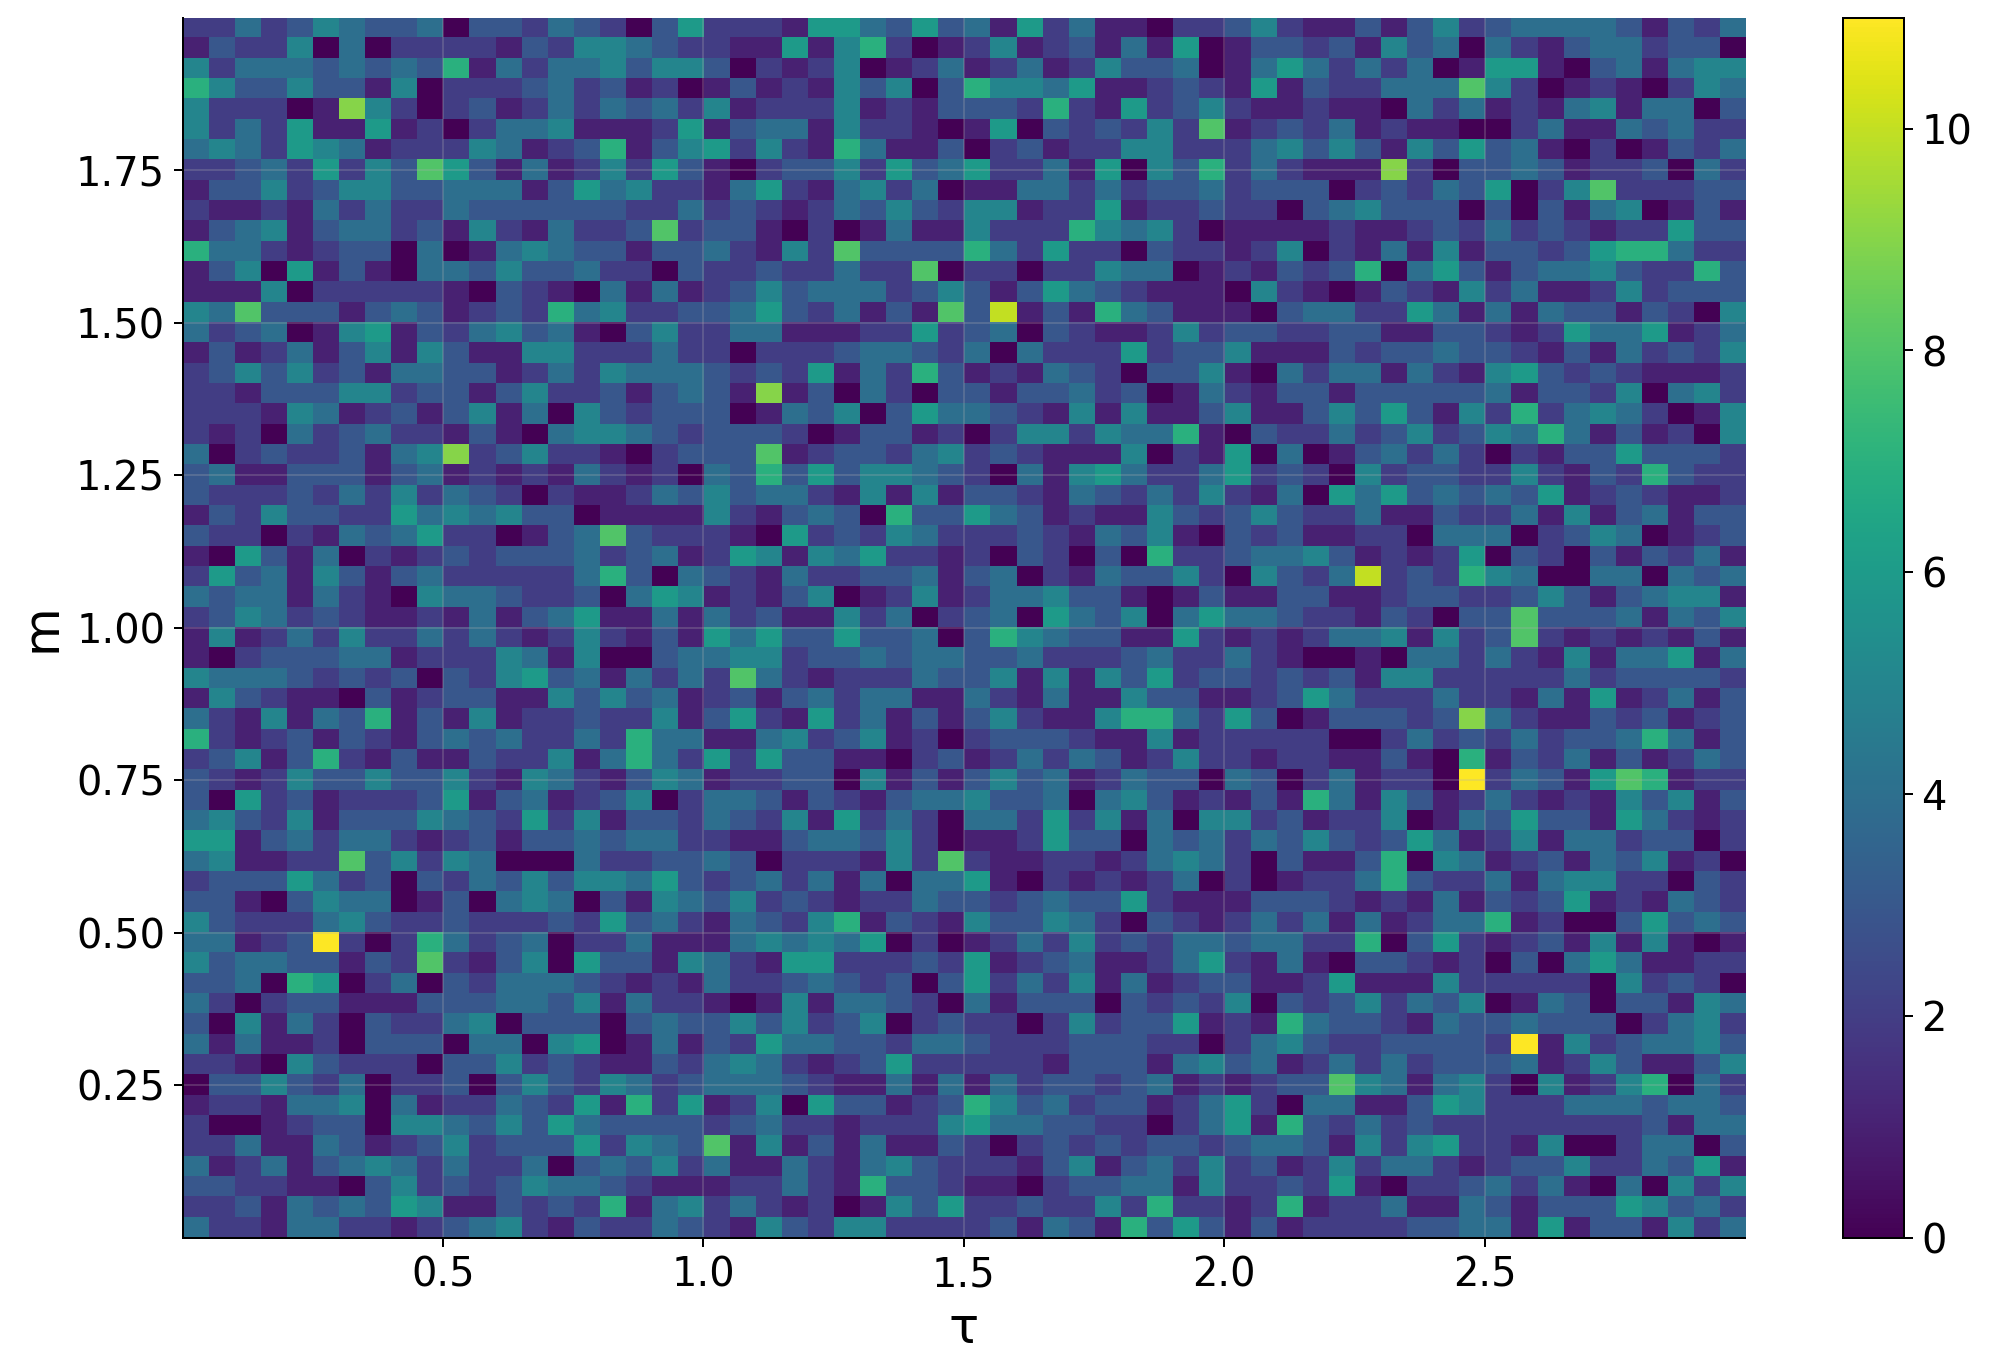

In [59]:
# Parametros editables + 5 llamadas explicitas
PROJECT_ROOT = find_project_root()
RUN_NAME = "PINN_mix_scaled_param"  # o PINN_mix_scaled
N_BINS = 60
WITH_TITLES = False

apply_plot_style(
    font_family="DejaVu Sans",
    font_size=14,
    axes_labelsize=18,
    tick_labelsize=16,
    legend_fontsize=14,
    axes_titlesize=16,
    figure_dpi=180,
    savefig_dpi=400,
    grid_alpha=0.25,
)

SCATTER_COLOR = "#1f77b4"
CDF_COLOR = "#ff7f0e"
HEATMAP_CMAP = "magma"
COUNT_CMAP = "viridis"

points_df = load_points(PROJECT_ROOT, RUN_NAME)
figures = {}

figures["scatter_pinn_vs_cos.png"] = plot_scatter_parity(
    points_df,
    title=f"{RUN_NAME} | PINN vs COS" if WITH_TITLES else "",
    color=SCATTER_COLOR,
    alpha=0.35,
    marker_size=14,
    points_label="PINN prices",
    diag_label="y = x",
    show_legend=True,
)

figures["abs_error_cdf.png"] = plot_abs_error_cdf(
    points_df,
    title=f"{RUN_NAME} | Absolute Error CDF" if WITH_TITLES else "",
    color=CDF_COLOR,
    line_width=1.8,
    show_legend=False,
)

figures["abs_error_map_m_tau.png"] = plot_heatmap(
    points_df,
    value_col="abs_error",
    cbar_label="",
    title=f"{RUN_NAME} | Mean Absolute Error" if WITH_TITLES else "",
    n_bins=N_BINS,
    cmap=HEATMAP_CMAP,
    log_scale=True,
)

figures["rel_abs_error_map_m_tau.png"] = plot_heatmap(
    points_df,
    value_col="rel_abs_error",
    cbar_label="",
    title=f"{RUN_NAME} | Mean Relative Absolute Error" if WITH_TITLES else "",
    n_bins=N_BINS,
    cmap=HEATMAP_CMAP,
    log_scale=True,
)

figures["counts_map_m_tau.png"] = plot_heatmap(
    points_df,
    value_col="count",
    cbar_label="",
    title=f"{RUN_NAME} | Samples per Zone" if WITH_TITLES else "",
    n_bins=N_BINS,
    cmap=COUNT_CMAP,
    log_scale=False,
)


In [60]:
# Guardado opcional
SAVE_FIGURES = True
OUT_DIR = PROJECT_ROOT / f"outputs/figures/pinn_pricing/{RUN_NAME}"

if SAVE_FIGURES:
    save_figures(figures, OUT_DIR, dpi=400)
else:
    print("SAVE_FIGURES=False. No se guarda nada.")


/Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM/outputs/figures/pinn_pricing/PINN_mix_scaled_param/scatter_pinn_vs_cos.png
/Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM/outputs/figures/pinn_pricing/PINN_mix_scaled_param/abs_error_cdf.png
/Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM/outputs/figures/pinn_pricing/PINN_mix_scaled_param/abs_error_map_m_tau.png
/Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM/outputs/figures/pinn_pricing/PINN_mix_scaled_param/rel_abs_error_map_m_tau.png
/Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM/outputs/figures/pinn_pricing/PINN_mix_scaled_param/counts_map_m_tau.png


## PIN Greeks


In [61]:
# Parametros PIN Greeks
PROJECT_ROOT = find_project_root()

GREEKS_VARIANTS = {
    "sobolev": {
        "bench_csv": PROJECT_ROOT / "outputs/protos/sobolev_mix/PINN_mix_scaled_param_v02/benchmark/points_pinn_vs_heston_cf_greeks.csv",
        "history_csv": PROJECT_ROOT / "outputs/protos/sobolev_mix/PINN_mix_scaled_param_v02/training/history.csv",
    },
    "no_sobolev": {
        "bench_csv": PROJECT_ROOT / "outputs/pinn/PINN_mix_scaled_param/greeks/benchmark_cf/points_pinn_vs_heston_cf_greeks.csv",
        "history_csv": None,
    },
}

GREEK_ORDER = ["delta", "gamma", "vega", "theta", "rho"]
GREEKS_N_BINS = 60
GREEKS_HIST_BINS = 140
GREEKS_WITH_TITLES = False
GREEKS_CMAP_ABS = "magma"
GREEKS_CMAP_REL = "magma"
GREEKS_HIST_COLOR = "#1f77b4"

greeks_data = {}
greeks_history = {}
for variant, cfg in GREEKS_VARIANTS.items():
    bench_csv = cfg["bench_csv"]
    if not bench_csv.exists():
        raise FileNotFoundError(bench_csv)
    greeks_data[variant] = pd.read_csv(bench_csv)

    history_csv = cfg.get("history_csv")
    if history_csv is not None:
        if not history_csv.exists():
            raise FileNotFoundError(history_csv)
        greeks_history[variant] = pd.read_csv(history_csv)

figures_greeks = {}


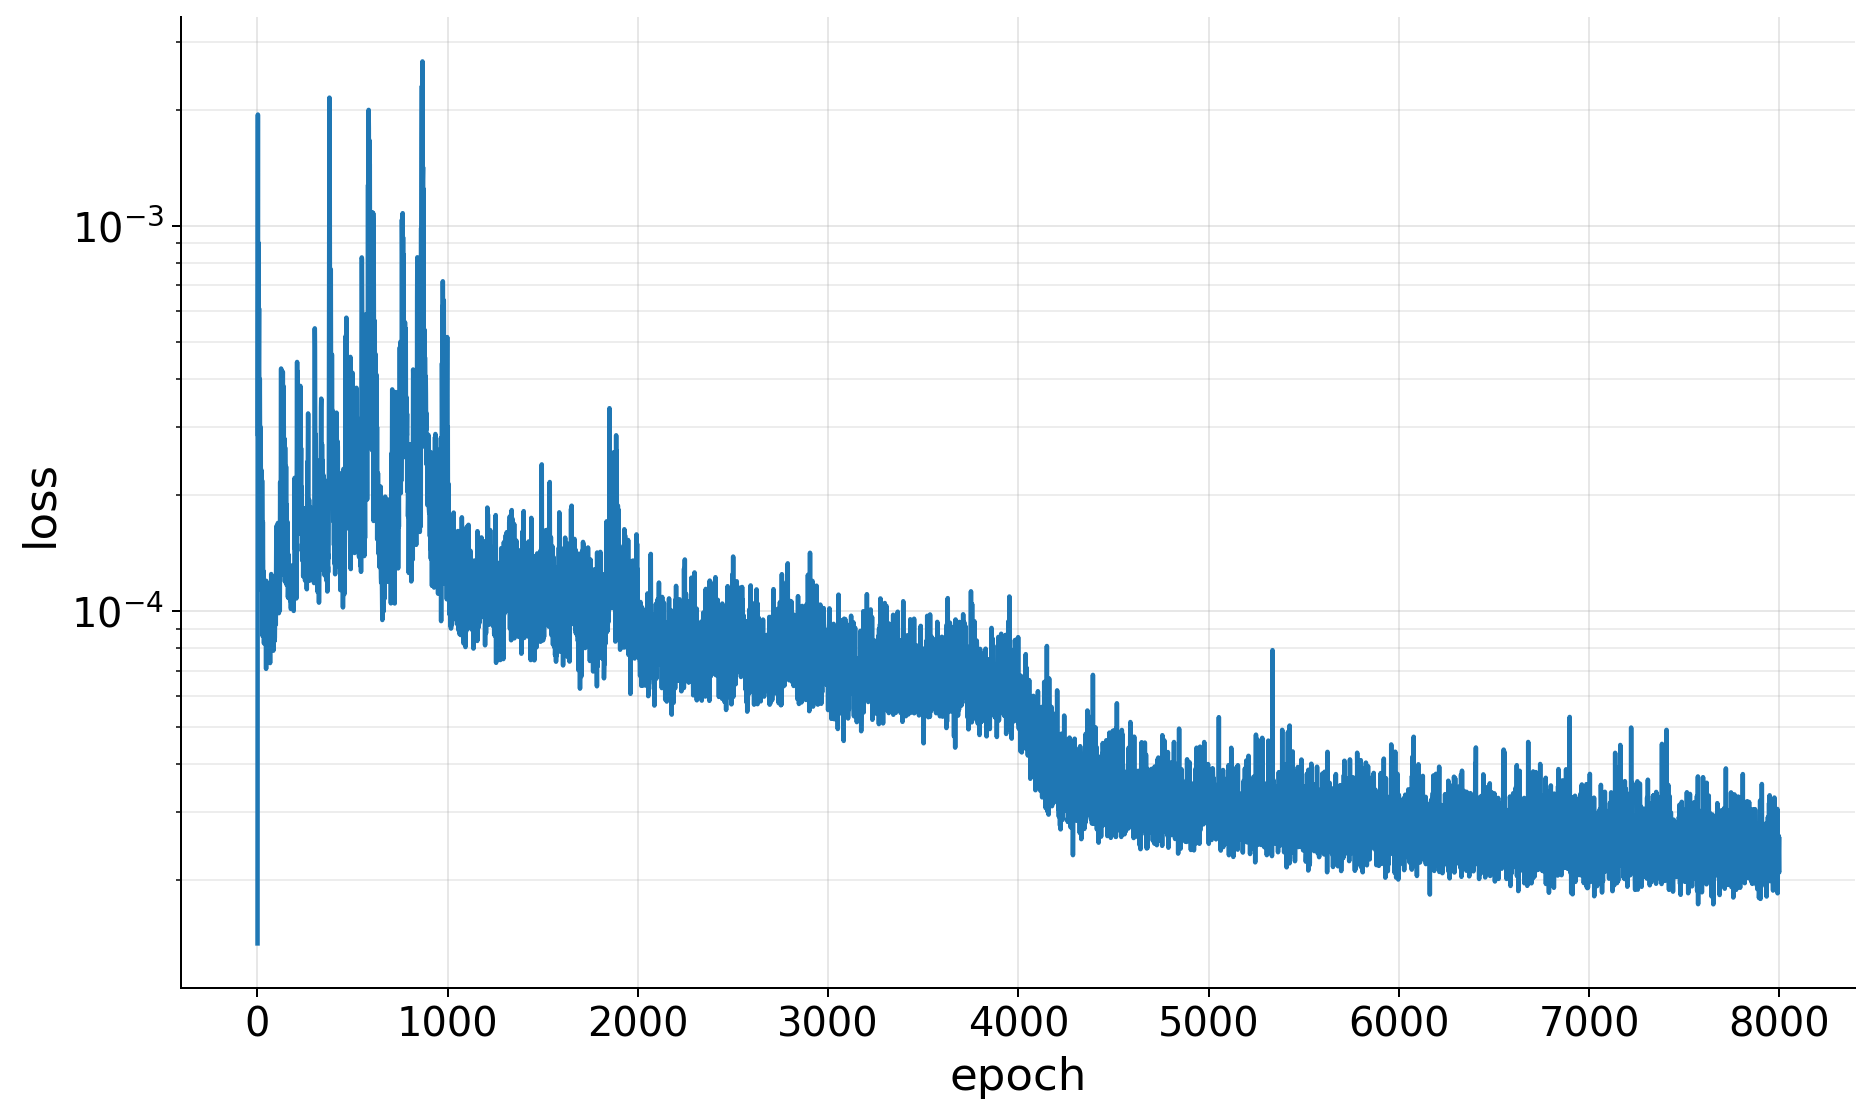

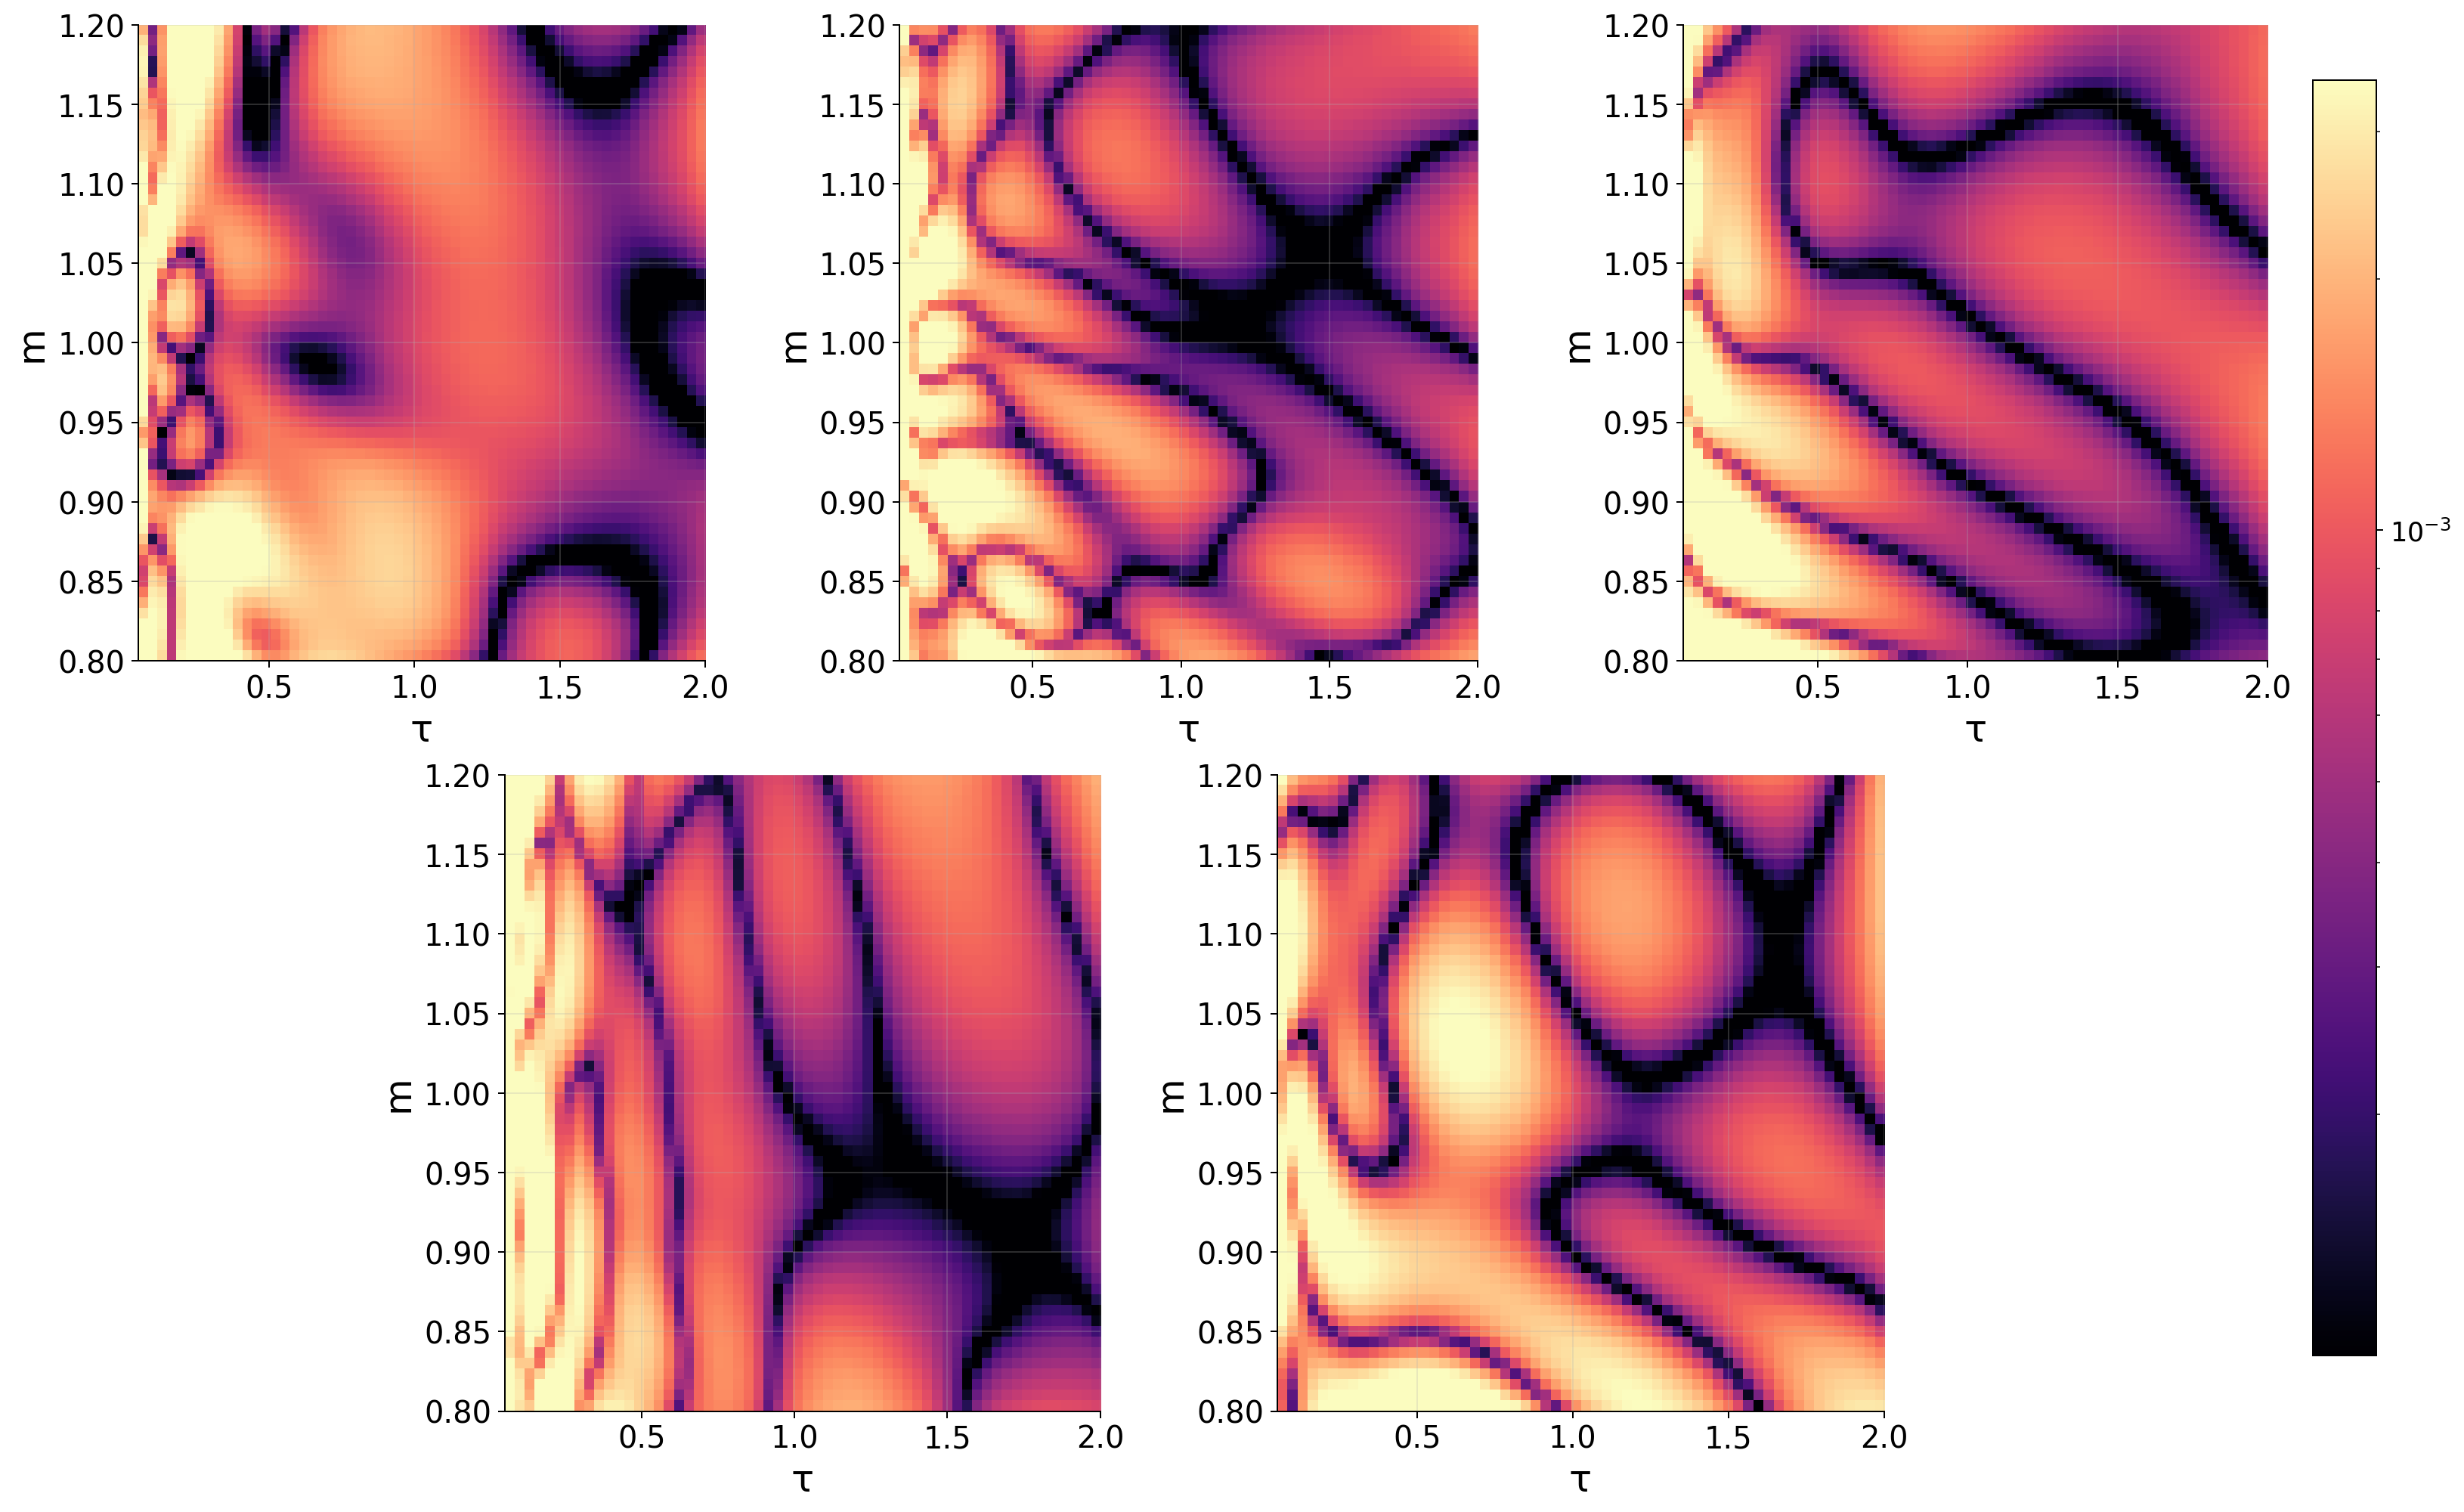

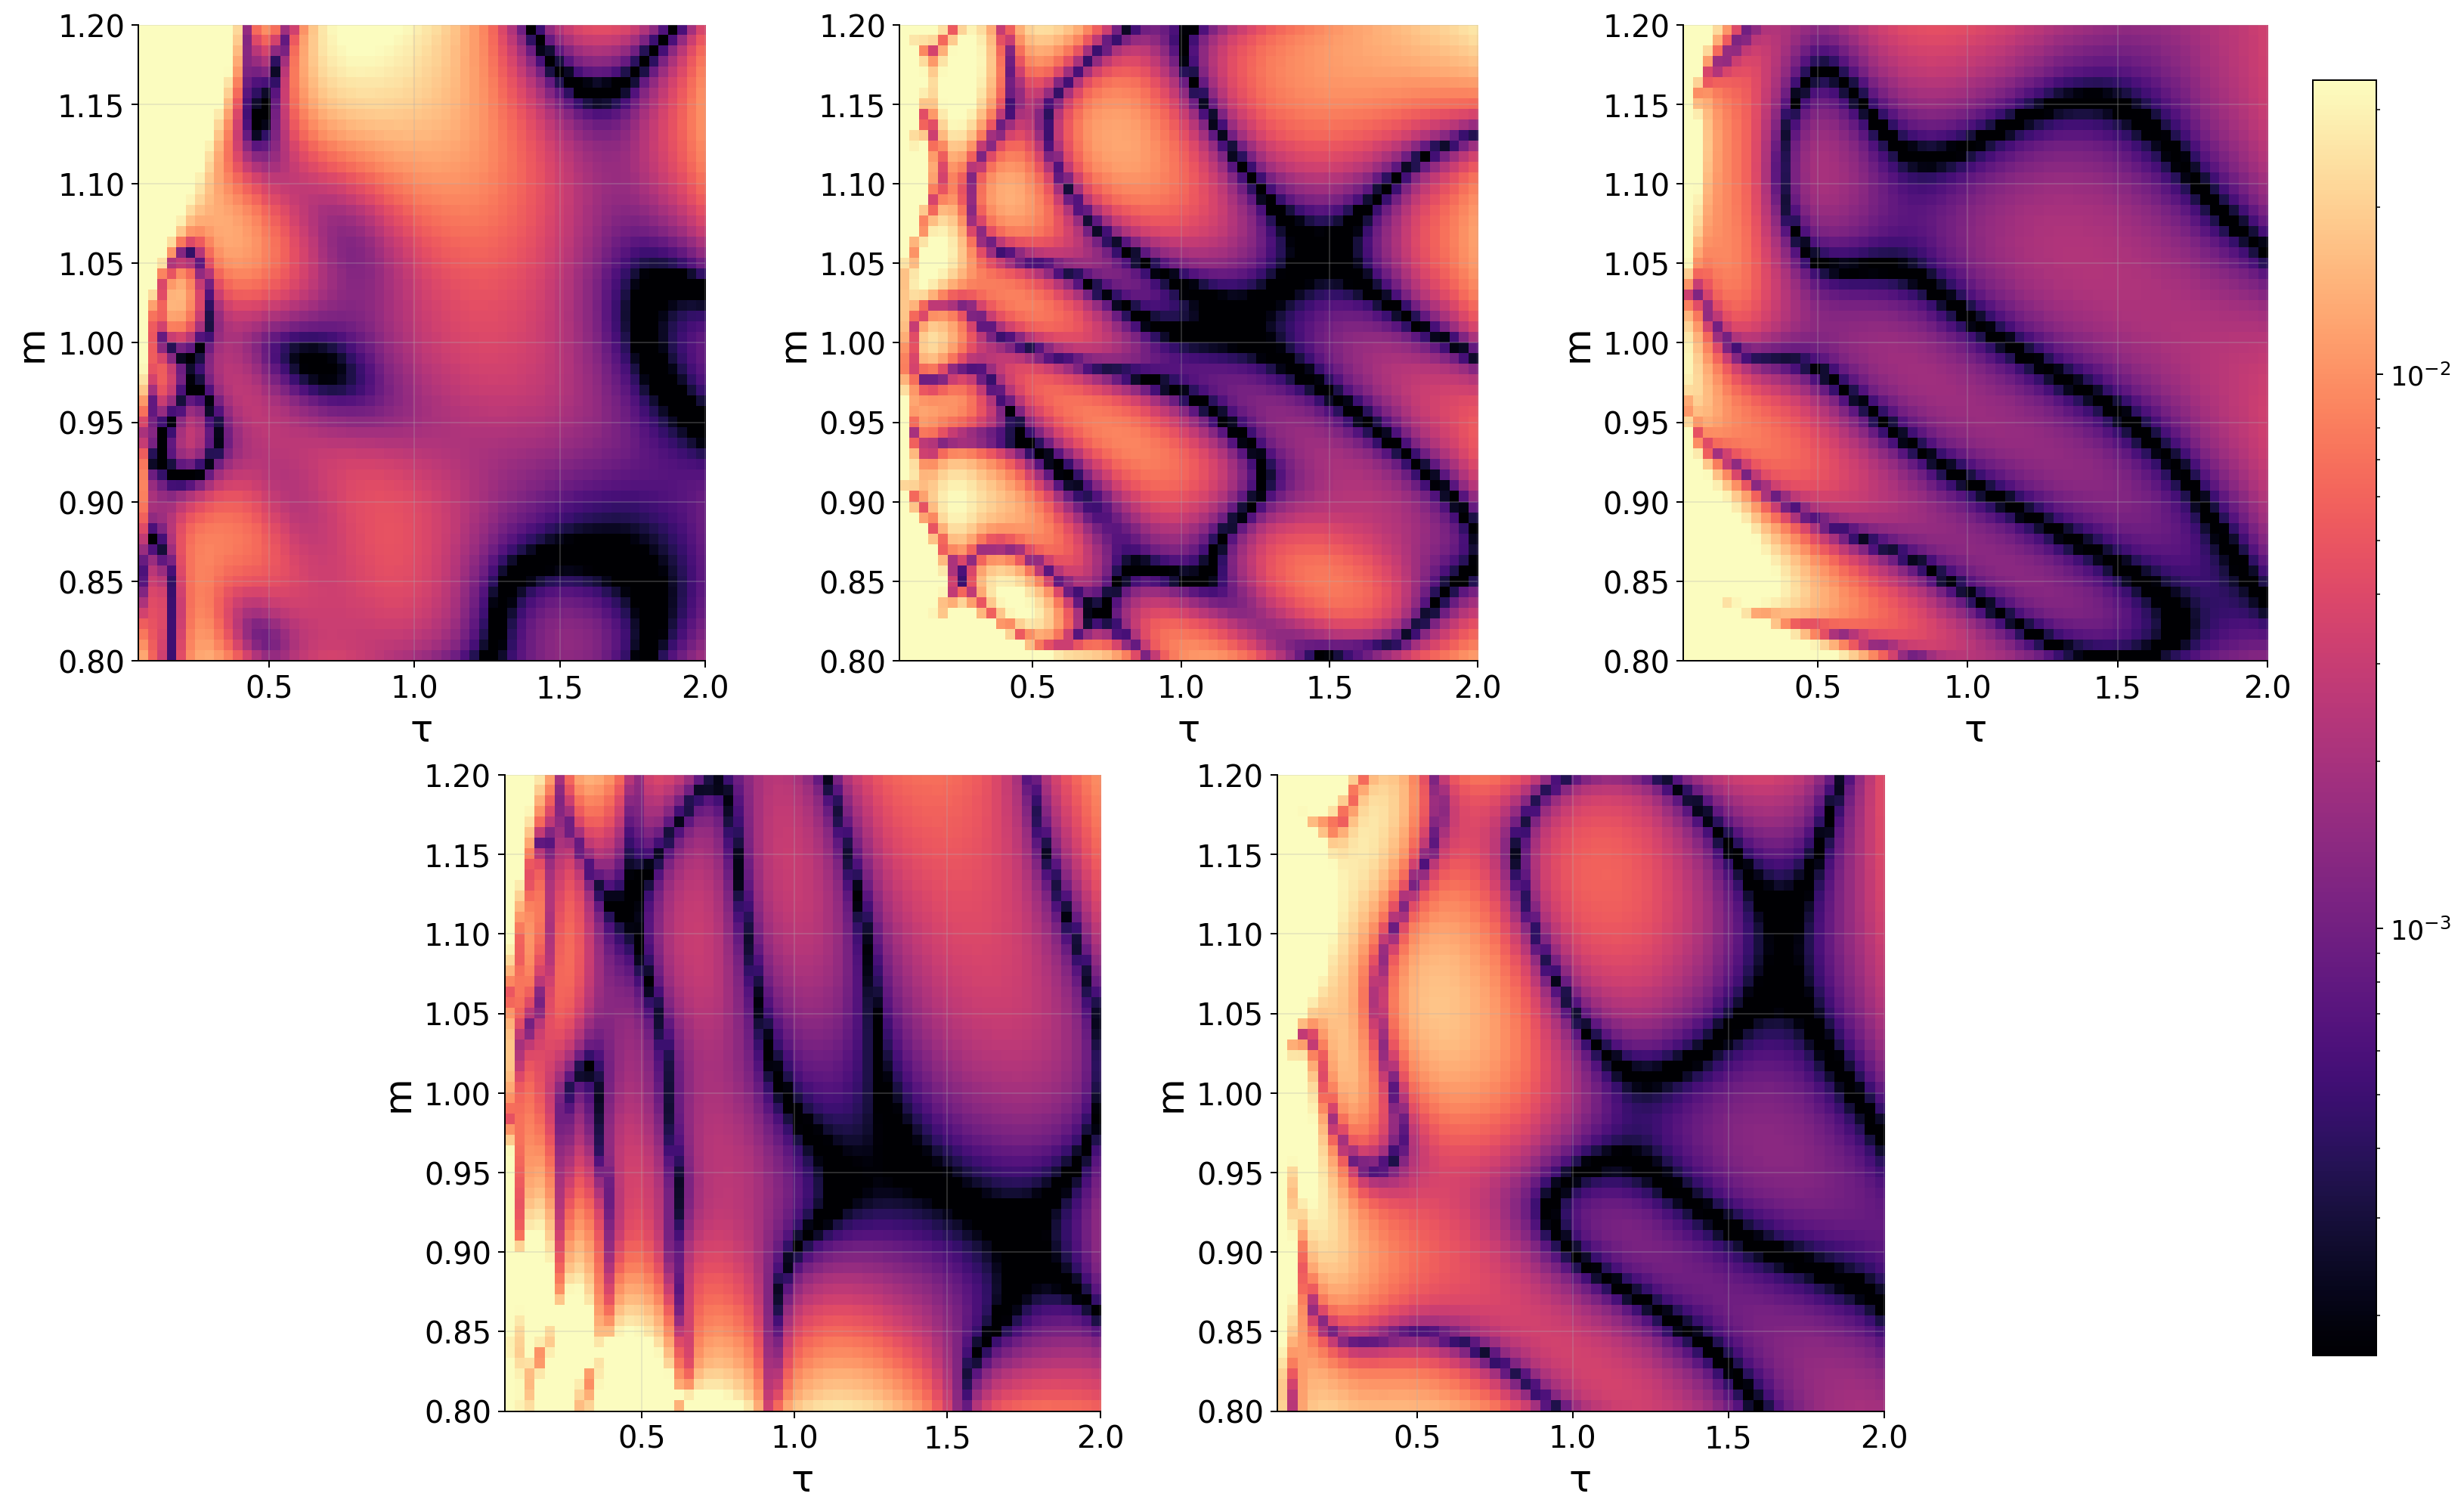

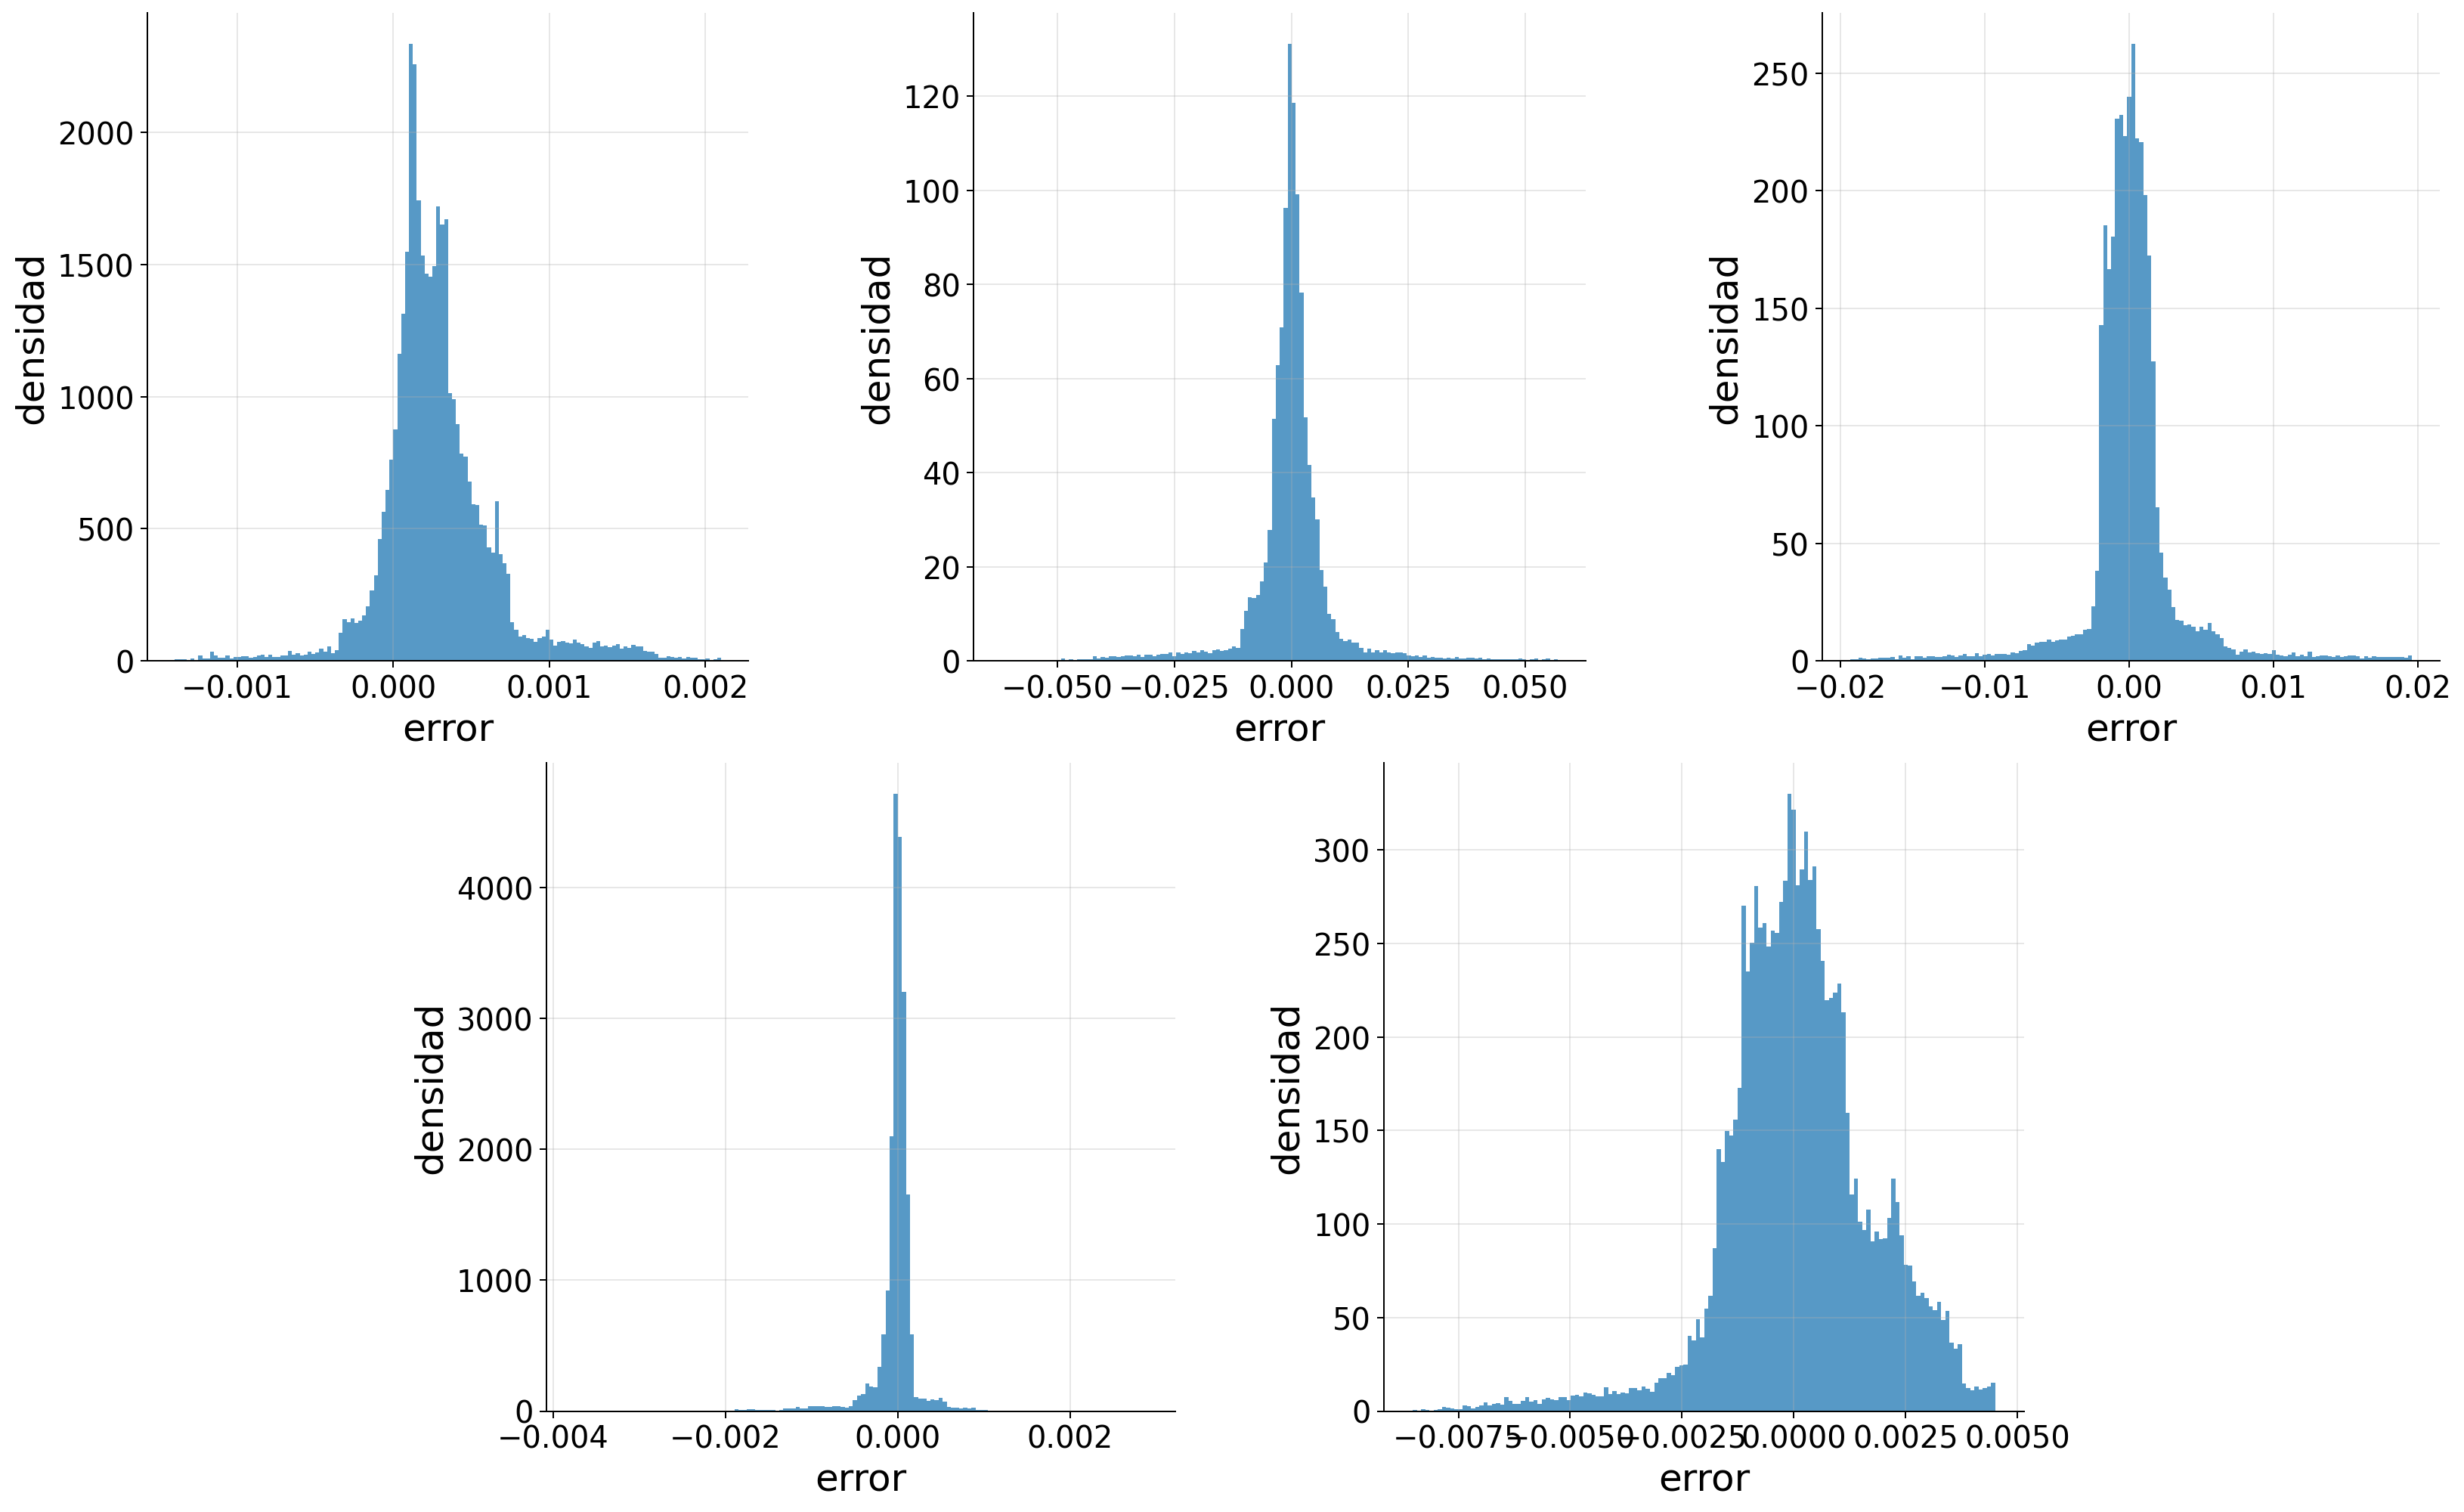

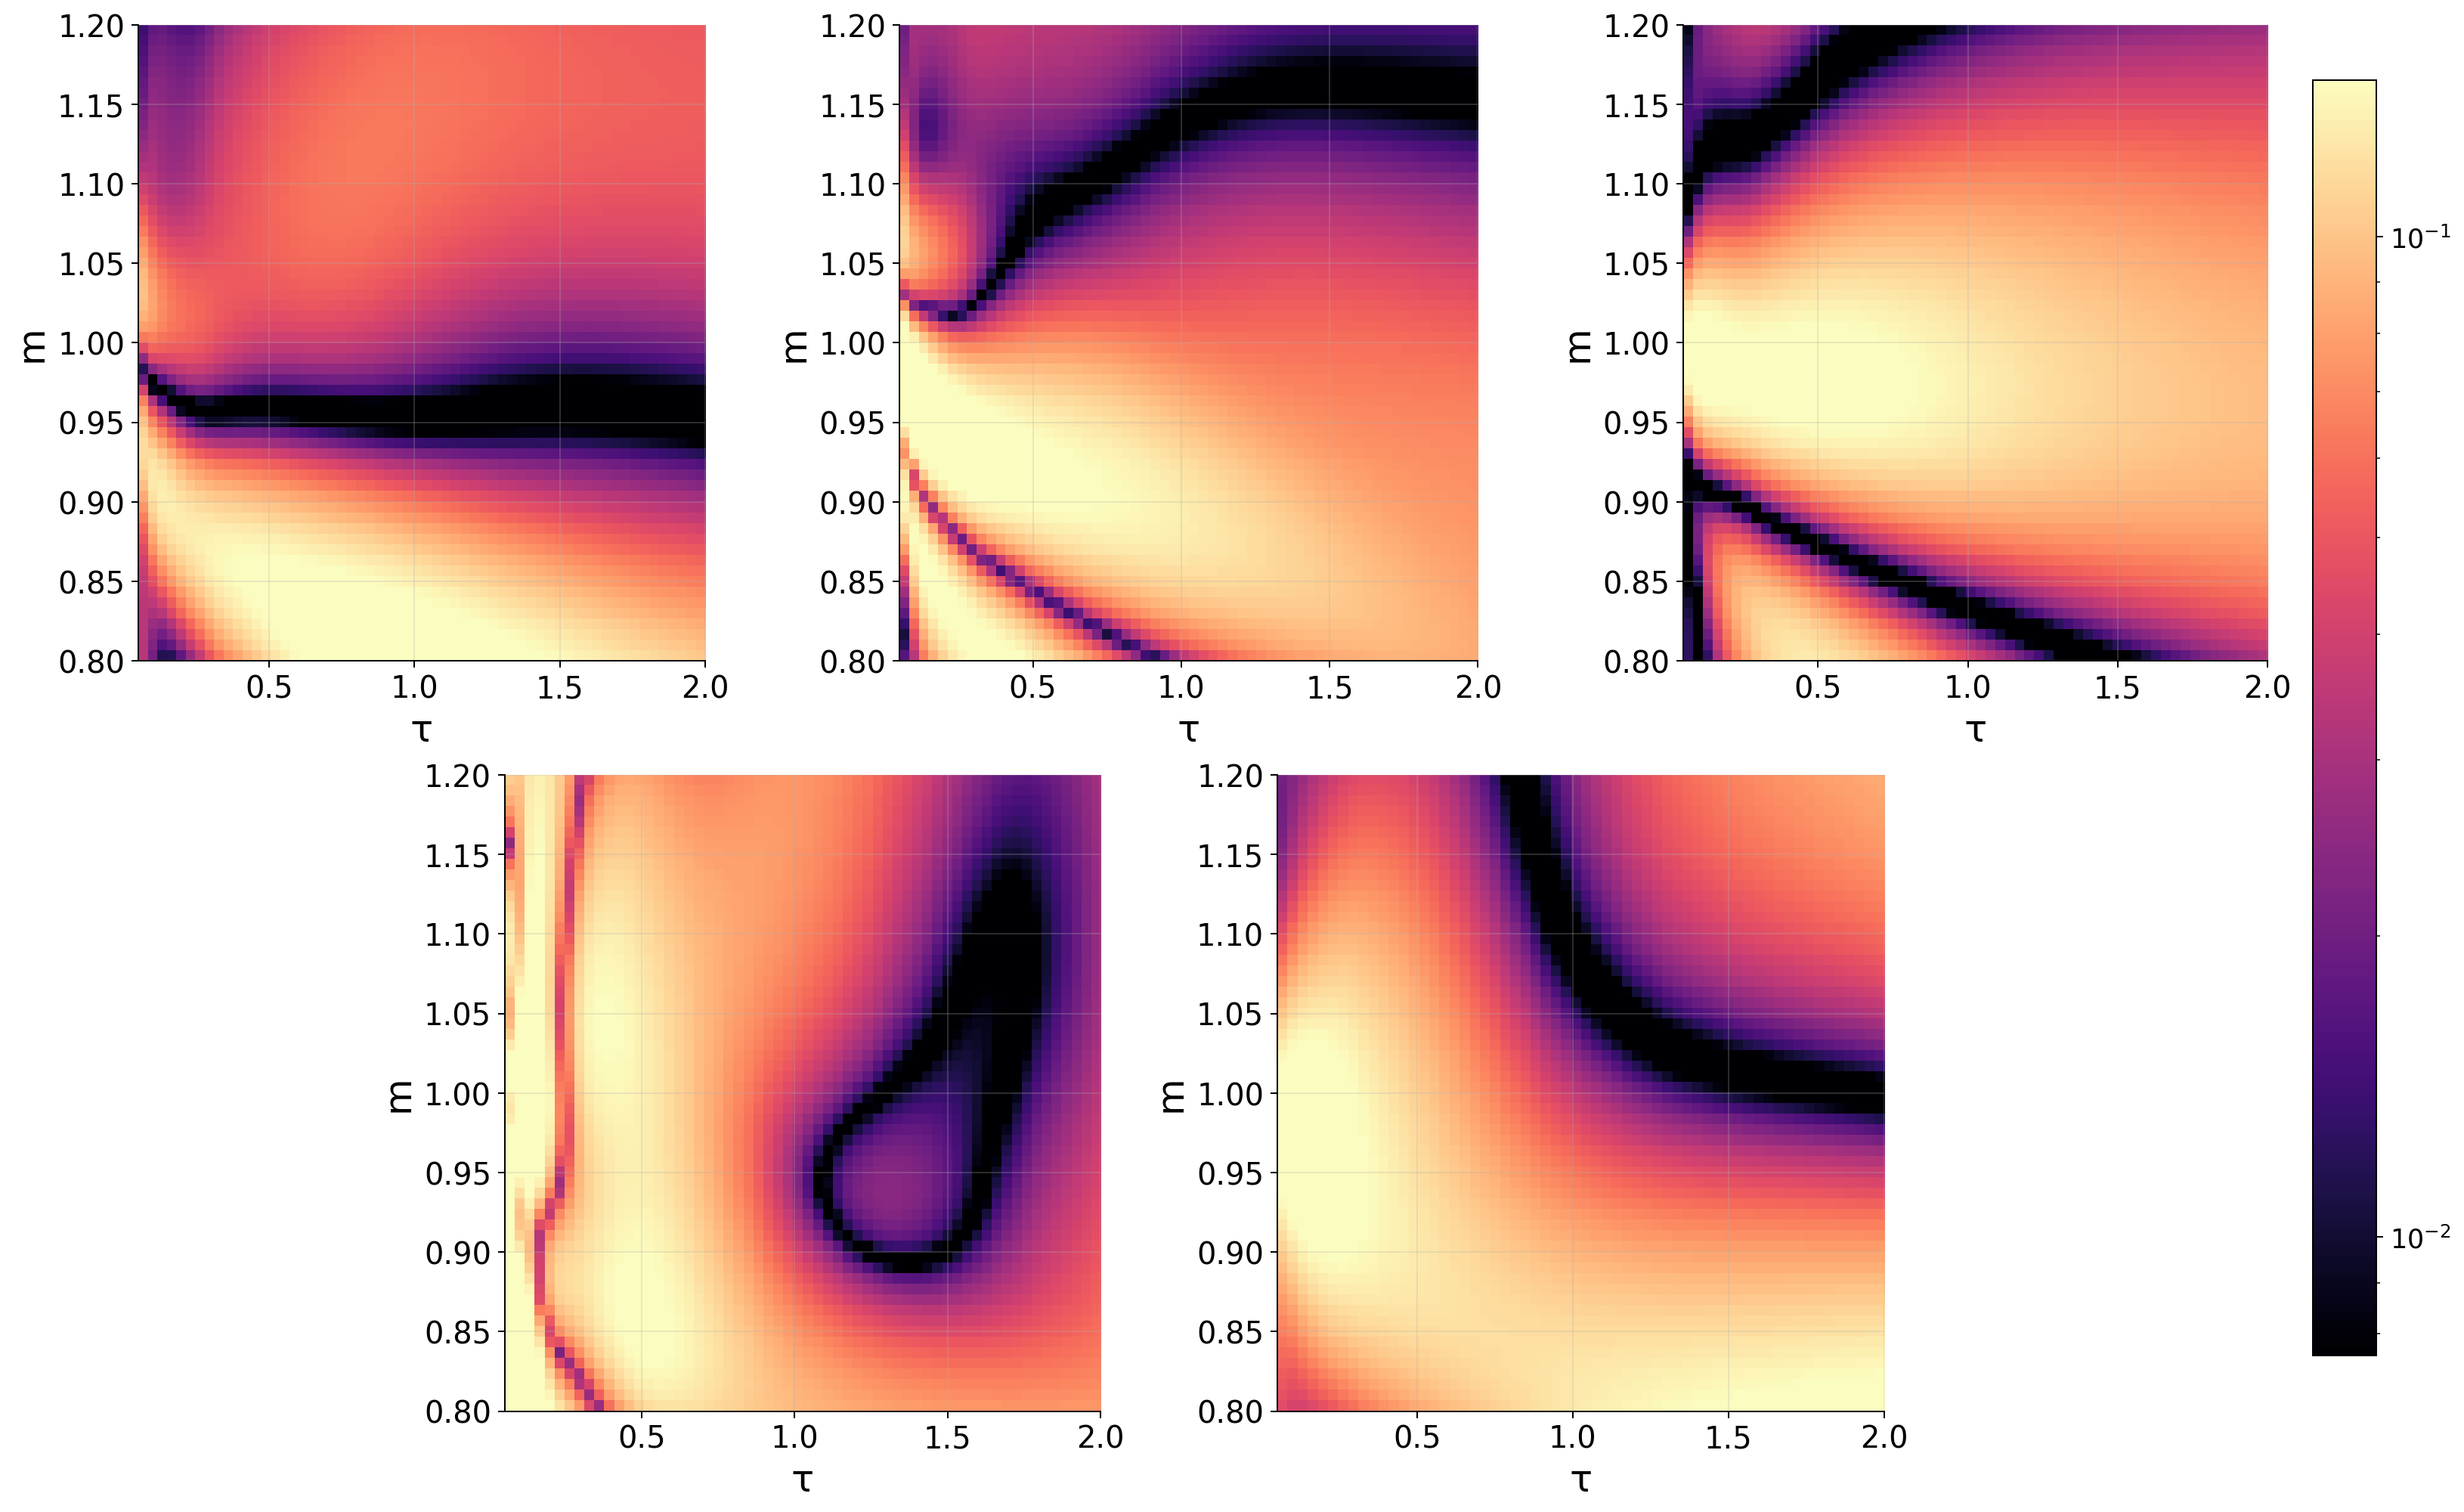

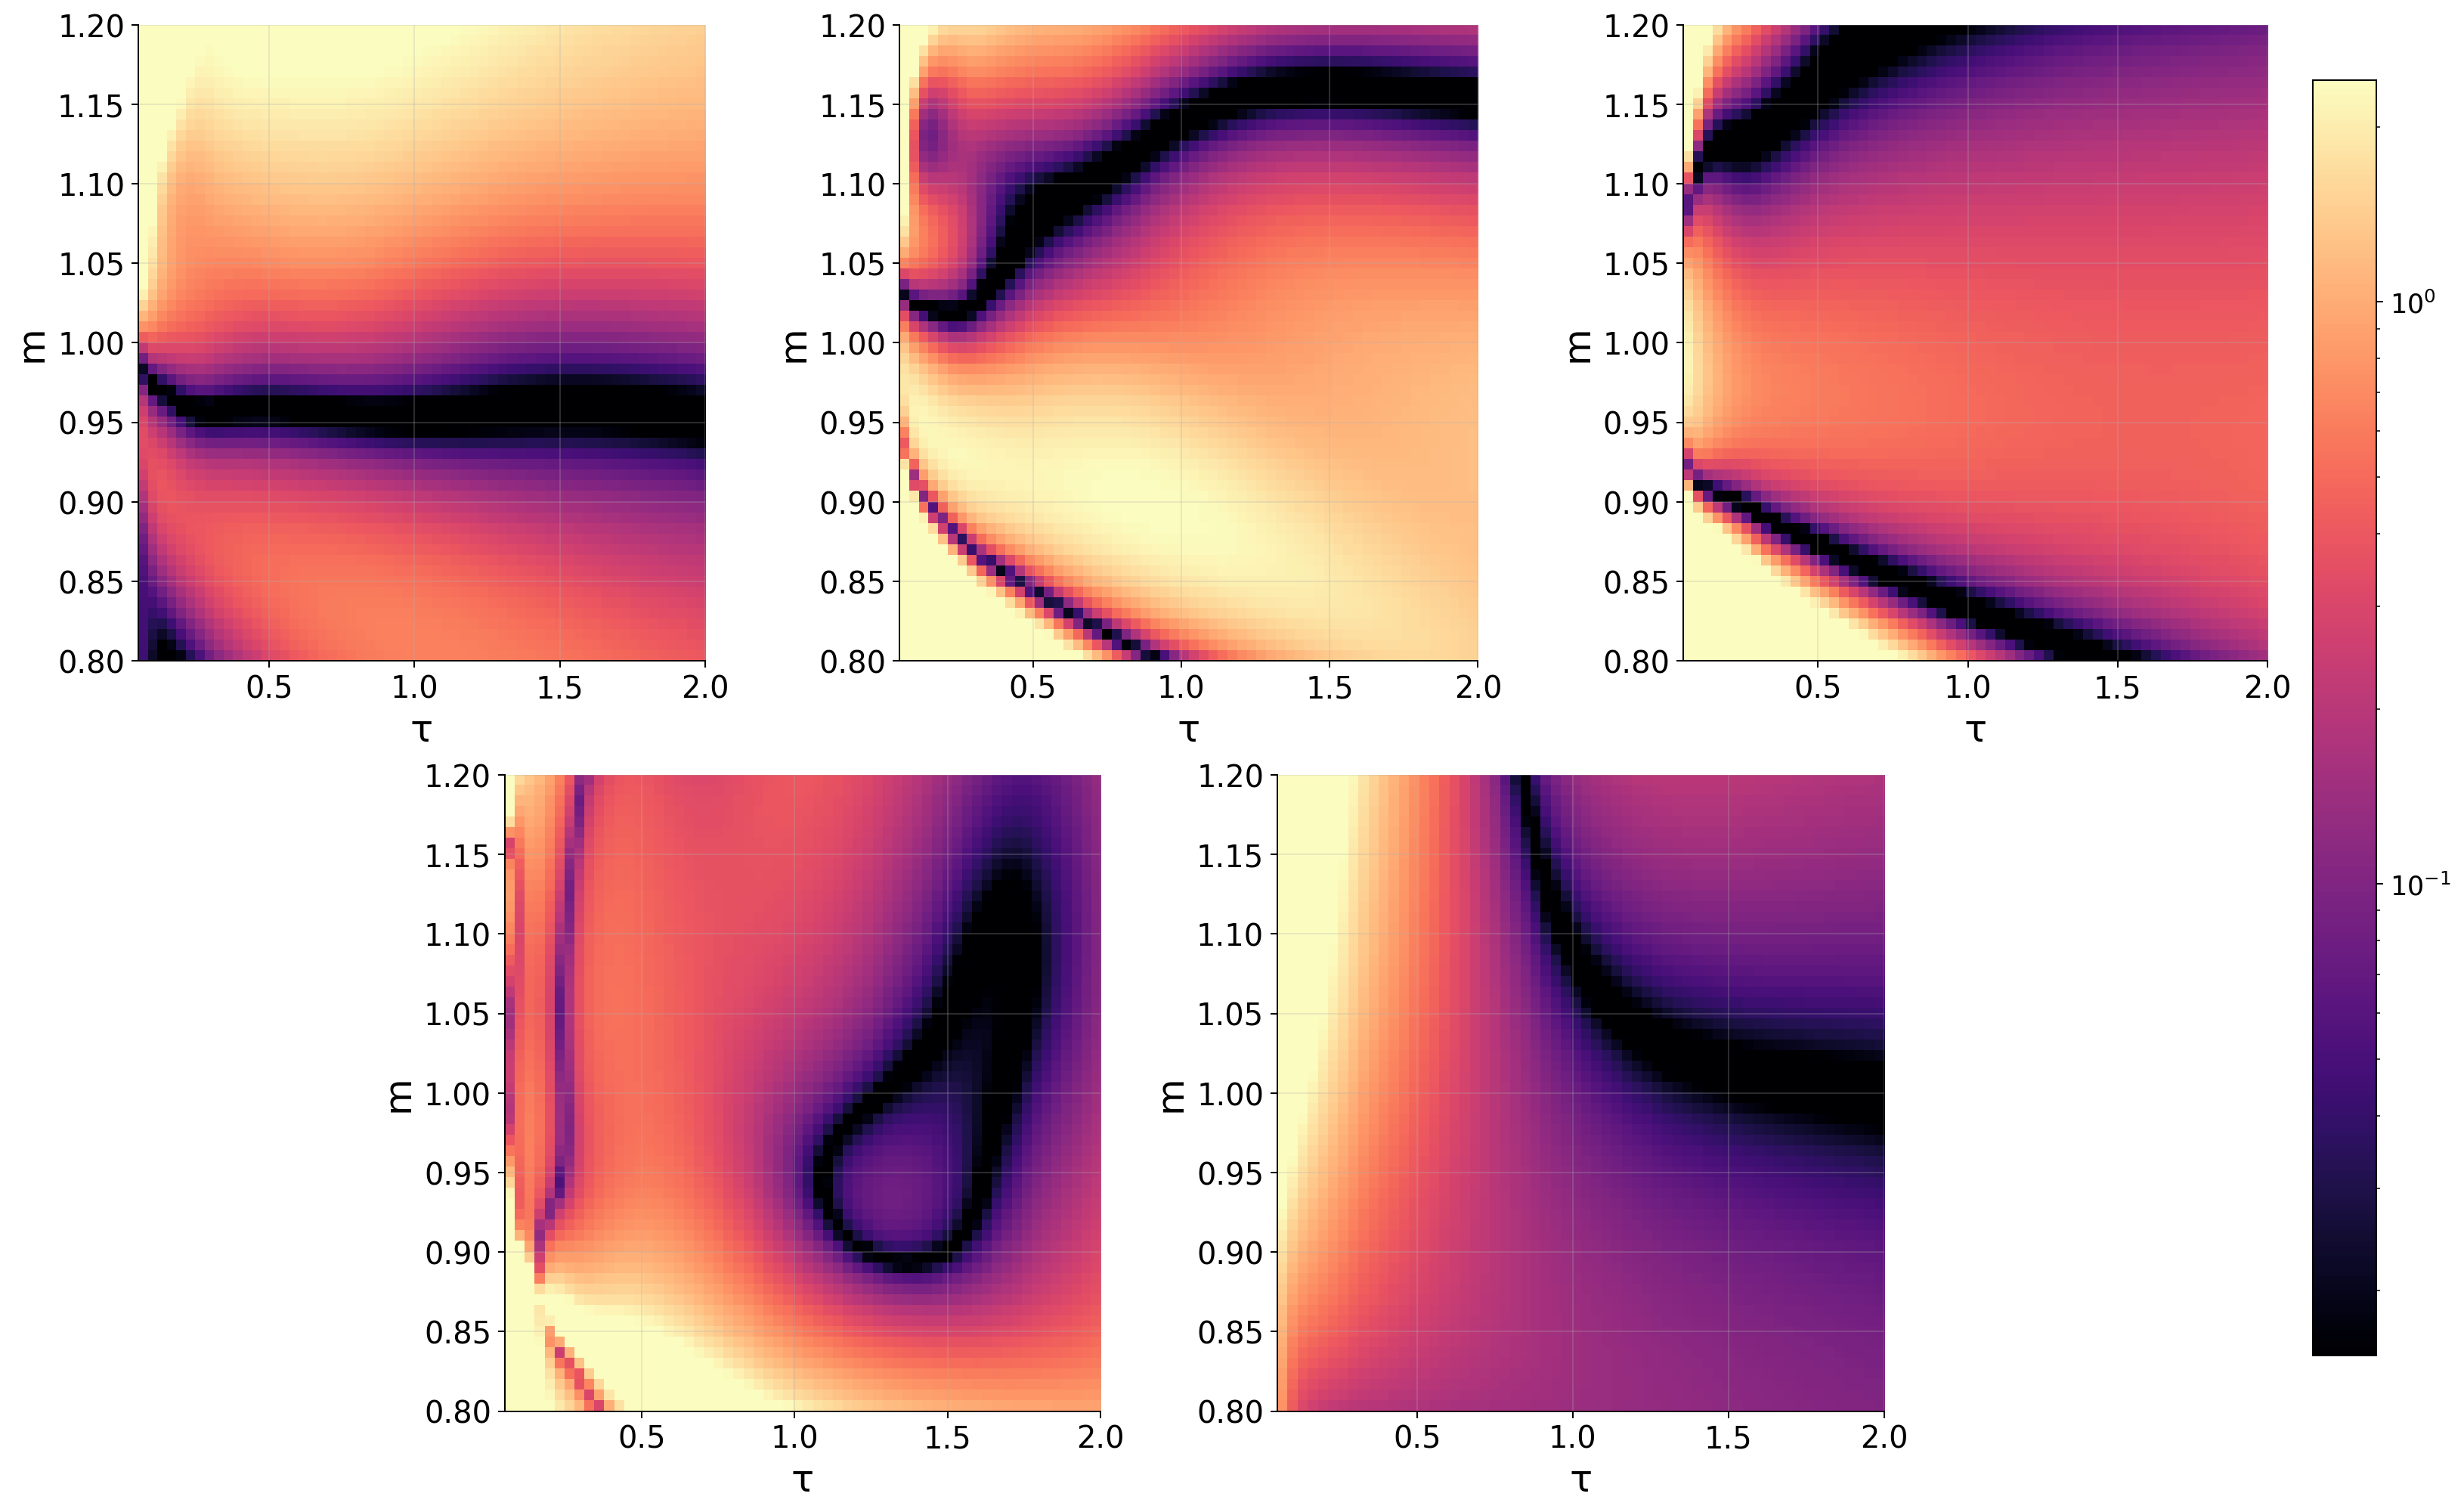

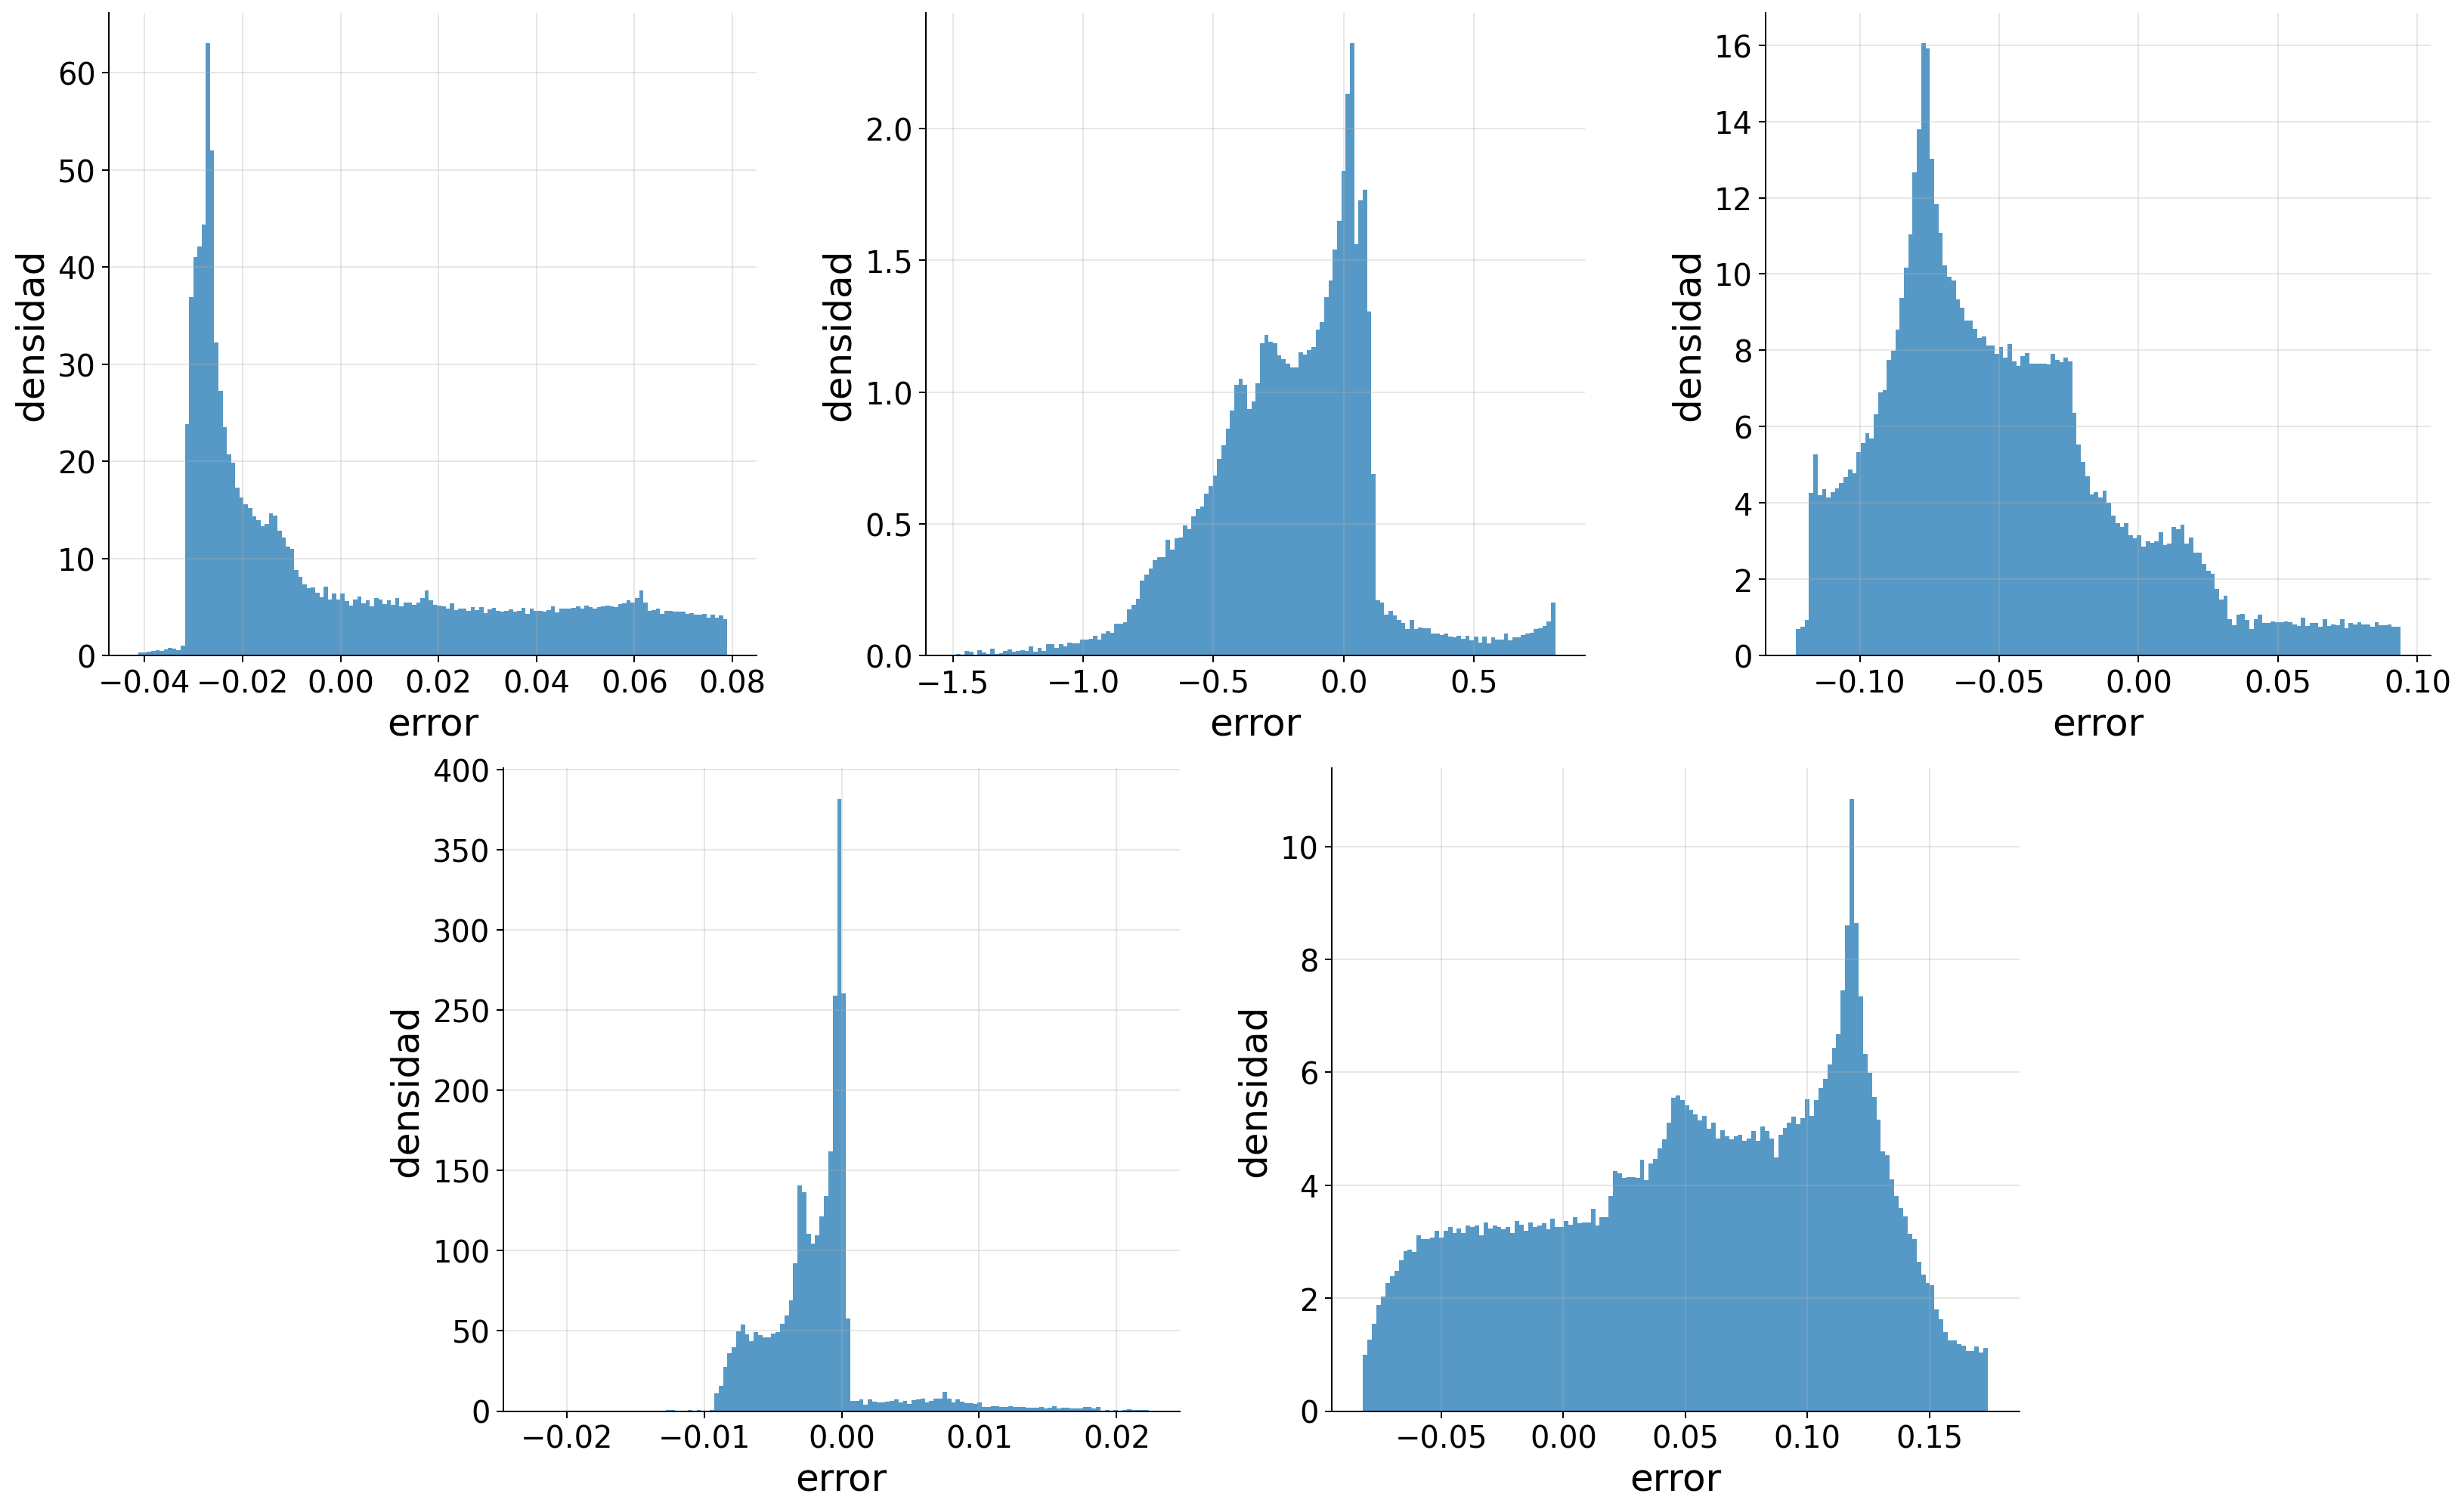

In [62]:
# Plots PIN Greeks: sobolev + no_sobolev (heatmaps abs/rel + hist panel 5x)
if "sobolev" in greeks_history:
    figures_greeks["sobolev_loss_curve.png"] = plot_loss_curve_from_history(
        greeks_history["sobolev"],
        title="" if not GREEKS_WITH_TITLES else "PINN training loss",
        figsize=(12, 7),
    )

for variant, df_variant in greeks_data.items():
    figures_greeks[f"{variant}_abs_error_maps_5greeks.png"] = plot_greek_error_panel(
        df_variant,
        metric_prefix="abs_error",
        greek_order=GREEK_ORDER,
        n_bins=GREEKS_N_BINS,
        cmap=GREEKS_CMAP_ABS,
        log_scale=True,
        cbar_label="",
        figsize=(18, 11),
        with_titles=GREEKS_WITH_TITLES,
    )

    figures_greeks[f"{variant}_rel_abs_error_maps_5greeks.png"] = plot_greek_error_panel(
        df_variant,
        metric_prefix="rel_abs_error",
        greek_order=GREEK_ORDER,
        n_bins=GREEKS_N_BINS,
        cmap=GREEKS_CMAP_REL,
        log_scale=True,
        cbar_label="",
        figsize=(18, 11),
        with_titles=GREEKS_WITH_TITLES,
    )

    figures_greeks[f"{variant}_error_hist_5greeks.png"] = plot_greek_hist_panel(
        df_variant,
        greek_order=GREEK_ORDER,
        bins=GREEKS_HIST_BINS,
        color=GREEKS_HIST_COLOR,
        alpha=0.75,
        figsize=(18, 11),
        with_titles=GREEKS_WITH_TITLES,
    )


In [63]:
# Guardado opcional PIN Greeks
SAVE_GREEKS_FIGURES = True
OUT_DIR_GREEKS = PROJECT_ROOT / "outputs/figures/pinn_greeks"

if SAVE_GREEKS_FIGURES:
    save_figures(figures_greeks, OUT_DIR_GREEKS, dpi=400)
else:
    print("SAVE_GREEKS_FIGURES=False. No se guarda nada.")


/Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM/outputs/figures/pinn_greeks/sobolev_loss_curve.png
/Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM/outputs/figures/pinn_greeks/sobolev_abs_error_maps_5greeks.png
/Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM/outputs/figures/pinn_greeks/sobolev_rel_abs_error_maps_5greeks.png
/Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM/outputs/figures/pinn_greeks/sobolev_error_hist_5greeks.png
/Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM/outputs/figures/pinn_greeks/no_sobolev_abs_error_maps_5greeks.png
/Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM/outputs/figures/pinn_greeks/no_sobolev_rel_abs_error_maps_5greeks.png
/Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM/outputs/figures/pinn_greeks/no_sobolev_error_hist_5greeks.png
